## This code runs the data for females through the pipeline to check whether each organ truly satisfies a power law. 

### 1. Load packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

### 2. Read in data

In [2]:
df = pd.read_csv("kleiber_males.csv")

print(df.shape)
print(df.head())

(131, 17)
   Age  Height  weight    SA  RMR-measured  MASS  weight.1    AT     SM  Bone  \
0   41    1.94   68.99  1.94          1464   NaN     68.99  20.7  22.85   3.8   
1   70    1.64   63.76  1.67          1392   NaN     63.76  20.8  19.47   4.0   
2   70    1.72   67.49  1.77          1610   NaN     67.49  16.3  26.04   4.0   
3   27    1.68   63.87  1.70          1597   NaN     63.87  15.1  31.64   4.1   
4   27    1.71   68.80  1.78          1735   NaN     68.80  18.5  25.65   4.1   

   Liver  Heart  Kidney  Spleen  Brain  Skin  Residual  
0  1.074  0.240   0.234   0.120  1.691   3.9      14.4  
1  1.168  0.211   0.230   0.271  1.681   3.3      12.6  
2  1.320  0.295   0.285   0.167  1.618   3.5      13.9  
3  1.347  0.288   0.231   0.334  1.543   3.4       5.9  
4  1.370  0.310   0.314   0.217  1.647   3.6      13.2  


### 3. Sniff Check Columns

In [3]:
df.columns = df.columns.str.strip()

print("Column names:")
for col in df.columns:
    print(col)

Column names:
Age
Height
weight
SA
RMR-measured
MASS
weight.1
AT
SM
Bone
Liver
Heart
Kidney
Spleen
Brain
Skin
Residual


### 4. Filter columns that have organ masses

In [4]:
# ======================================================
# Chunk F04
# Define analysis columns and create clean organ dataset
# ======================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------
# Define body weight, REE, and body-composition columns
# ------------------------------------------------------

weight_col = "weight"
ree_col = "RMR-measured"

organ_cols = [
    "AT",
    "SM",
    "Bone",
    "Liver",
    "Heart",
    "Kidney",
    "Spleen",
    "Brain",
    "Skin",
    "Residual"
]

# ------------------------------------------------------
# Friendly names for plots and tables
# ------------------------------------------------------

organ_name_map = {
    "AT": "Adipose Tissue",
    "SM": "Skeletal Muscle",
    "Bone": "Bone",
    "Liver": "Liver",
    "Heart": "Heart",
    "Kidney": "Kidneys",
    "Spleen": "Spleen",
    "Brain": "Brain",
    "Skin": "Skin",
    "Residual": "Remaining Mass"
}

# ------------------------------------------------------
# Keep only relevant columns
# ------------------------------------------------------

analysis_cols = [weight_col, ree_col] + organ_cols

organ_df = df[analysis_cols].copy()

# ------------------------------------------------------
# Force numeric conversion
# ------------------------------------------------------

for col in analysis_cols:
    organ_df[col] = pd.to_numeric(
        organ_df[col],
        errors="coerce"
    )

# ------------------------------------------------------
# Replace infinite values
# ------------------------------------------------------

organ_df = organ_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# ------------------------------------------------------
# Basic diagnostics
# ------------------------------------------------------

print("Analysis data:")
display(organ_df.head())

print("\nSummary statistics:")
display(organ_df.describe())

print("\nMissing values by column:")
display(organ_df.isna().sum())

print("\nUsable positive observations:")

for organ in organ_cols:

    temp = organ_df[
        [weight_col, organ]
    ].dropna()

    temp = temp[
        (temp[weight_col] > 0)
        & (temp[organ] > 0)
    ]

    print(
        f"{organ_name_map[organ]} ({organ}): {len(temp)}"
    )

Analysis data:


,weight,RMR-measured,AT,SM,Bone,Liver,Heart,Kidney,Spleen,Brain,Skin,Residual
0,68.99,1464,20.7,22.85,3.8,1.074,0.240,0.234,0.120,1.691,3.9,14.4
1,63.76,1392,20.8,19.47,4.0,1.168,0.211,0.230,0.271,1.681,3.3,12.6
2,67.49,1610,16.3,26.04,4.0,1.320,0.295,0.285,0.167,1.618,3.5,13.9
3,63.87,1597,15.1,31.64,4.1,1.347,0.288,0.231,0.334,1.543,3.4,5.9
4,68.80,1735,18.5,25.65,4.1,1.370,0.310,0.314,0.217,1.647,3.6,13.2



Summary statistics:


,weight,RMR-measured,AT,SM,Bone,Liver,Heart,Kidney,Spleen,Brain,Skin,Residual
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,87.048779,1810.435115,24.988702,31.846718,5.244962,1.781611,0.325527,0.333672,0.300573,1.611287,4.054809,16.568550
std,15.609791,251.365382,9.836844,5.511689,0.722594,0.352964,0.086794,0.061680,0.118620,0.113899,0.369730,3.933382
min,54.750000,1177.000000,8.030000,19.470000,3.800000,1.030000,0.130000,0.202000,0.086000,1.343000,3.150000,5.900000
25%,75.070000,1615.500000,18.400000,28.010000,4.700000,1.538000,0.273500,0.301000,0.219500,1.530000,3.800000,13.850000
50%,87.000000,1798.000000,24.260000,31.550000,5.200000,1.732000,0.324000,0.326000,0.290000,1.595000,4.050000,16.600000
75%,95.380000,1966.500000,30.400000,34.910000,5.700000,1.991500,0.379000,0.372500,0.366500,1.681000,4.300000,19.180000
max,137.100000,2729.000000,54.000000,49.660000,7.540000,2.870000,0.573000,0.520000,0.670000,1.963000,5.100000,32.000000



Missing values by column:


weight          0
RMR-measured    0
AT              0
SM              0
Bone            0
Liver           0
Heart           0
Kidney          0
Spleen          0
Brain           0
Skin            0
Residual        0
dtype: int64


Usable positive observations:
Adipose Tissue (AT): 131
Skeletal Muscle (SM): 131
Bone (Bone): 131
Liver (Liver): 131
Heart (Heart): 131
Kidneys (Kidney): 131
Spleen (Spleen): 131
Brain (Brain): 131
Skin (Skin): 131
Remaining Mass (Residual): 131


### 5. Load Organ Metabolic Rate Columns (my $K_i$ from Elia). I deleted these for males.

### 6. Check Missing Values

In [5]:
print("Missing values:")
display(organ_df.isna().sum())

print("\nPositive value counts:")
for organ in organ_cols:
    temp = organ_df[[weight_col, organ]].dropna()
    temp = temp[(temp[weight_col] > 0) & (temp[organ] > 0)]
    print(f"{organ}: {len(temp)} usable rows")

Missing values:


weight          0
RMR-measured    0
AT              0
SM              0
Bone            0
Liver           0
Heart           0
Kidney          0
Spleen          0
Brain           0
Skin            0
Residual        0
dtype: int64


Positive value counts:
AT: 131 usable rows
SM: 131 usable rows
Bone: 131 usable rows
Liver: 131 usable rows
Heart: 131 usable rows
Kidney: 131 usable rows
Spleen: 131 usable rows
Brain: 131 usable rows
Skin: 131 usable rows
Residual: 131 usable rows


### 7. Function to Fit Power Law

In [6]:
# ======================================================
# Chunk 7
# Define power-law fitting function with alpha and beta CIs
# Model: y = alpha * x^beta
# ======================================================

def fit_power_law(data, x_col, y_col):
    temp = data[[x_col, y_col]].copy()

    temp[x_col] = pd.to_numeric(temp[x_col], errors="coerce")
    temp[y_col] = pd.to_numeric(temp[y_col], errors="coerce")

    temp = temp.replace([np.inf, -np.inf], np.nan)
    temp = temp.dropna()
    temp = temp[(temp[x_col] > 0) & (temp[y_col] > 0)].copy()

    temp["log_x"] = np.log(temp[x_col])
    temp["log_y"] = np.log(temp[y_col])

    X = sm.add_constant(temp["log_x"])
    y = temp["log_y"]

    model = sm.OLS(y, X).fit()

    log_alpha = model.params["const"]
    beta = model.params["log_x"]

    alpha = np.exp(log_alpha)

    ci = model.conf_int()

    log_alpha_ci_lower = ci.loc["const", 0]
    log_alpha_ci_upper = ci.loc["const", 1]

    alpha_ci_lower = np.exp(log_alpha_ci_lower)
    alpha_ci_upper = np.exp(log_alpha_ci_upper)

    beta_ci_lower = ci.loc["log_x", 0]
    beta_ci_upper = ci.loc["log_x", 1]

    temp["log_predicted"] = model.predict(X)
    temp["log_residual"] = temp["log_y"] - temp["log_predicted"]

    temp["predicted_original"] = alpha * temp[x_col] ** beta
    temp["residual_original"] = temp[y_col] - temp["predicted_original"]

    results = {
        "organ": y_col,
        "n": len(temp),

        "alpha": alpha,
        "alpha_ci_lower": alpha_ci_lower,
        "alpha_ci_upper": alpha_ci_upper,

        "beta": beta,
        "beta_ci_lower": beta_ci_lower,
        "beta_ci_upper": beta_ci_upper,

        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
        "log_residual_sd": temp["log_residual"].std(ddof=1)
    }

    return model, temp, results

### 8. Function for Quadratic Curve term stress test

In [7]:
# ======================================================
# Chunk 8
# Curvature stress test for power-law assumption
# Model: log_y = a + b log_x + c(log_x)^2
# ======================================================

def curvature_stress_test(temp):
    temp = temp.copy()

    required_cols = ["log_x", "log_y"]

    missing_cols = [
        col for col in required_cols
        if col not in temp.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing required columns: {missing_cols}. "
            "Run fit_power_law first so temp contains log_x and log_y."
        )

    temp["log_x_sq"] = temp["log_x"] ** 2

    X_quad = sm.add_constant(
        temp[["log_x", "log_x_sq"]]
    )

    y = temp["log_y"]

    quad_model = sm.OLS(y, X_quad).fit()

    c = quad_model.params["log_x_sq"]
    p_c = quad_model.pvalues["log_x_sq"]
    c_ci = quad_model.conf_int().loc["log_x_sq"]

    if p_c > 0.05:
        result = "Pass: no evidence of curvature"
    else:
        result = "Fail: evidence of curvature"

    curvature_results = {
        "n": len(temp),
        "curvature_c": c,
        "curvature_p": p_c,
        "curvature_ci_lower": c_ci[0],
        "curvature_ci_upper": c_ci[1],
        "curvature_result": result,
        "quad_r_squared": quad_model.rsquared
    }

    return quad_model, curvature_results

### 9. Run Power Law Fit for all Organs

In [8]:
all_results = []
models = {}
cleaned_data = {}
quad_models = {}

for organ in organ_cols:
    print(f"Running: {organ}")

    model, temp, results = fit_power_law(
        data=organ_df,
        x_col=weight_col,
        y_col=organ
    )

    quad_model, curvature_results = curvature_stress_test(temp)

    results.update(curvature_results)

    all_results.append(results)
    models[organ] = model
    cleaned_data[organ] = temp
    quad_models[organ] = quad_model

summary_table = pd.DataFrame(all_results)

display(summary_table)

Running: AT
Running: SM
Running: Bone
Running: Liver
Running: Heart
Running: Kidney
Running: Spleen
Running: Brain
Running: Skin
Running: Residual


,organ,n,alpha,alpha_ci_lower,alpha_ci_upper,beta,beta_ci_lower,beta_ci_upper,r_squared,adj_r_squared,log_residual_sd,curvature_c,curvature_p,curvature_ci_lower,curvature_ci_upper,curvature_result,quad_r_squared
0,AT,131,0.003903,0.001418,0.010744,1.951050,1.723726,2.178373,0.690912,0.688516,0.229429,-0.390305,0.446783,-1.402287,0.621676,Pass: no evidence of curvature,0.692312
1,SM,131,1.040409,0.652761,1.658263,0.765393,0.660743,0.870043,0.618792,0.615837,0.105619,0.114561,0.627860,-0.351941,0.581063,Pass: no evidence of curvature,0.619494
2,Bone,131,1.785999,1.008579,3.162660,0.239956,0.111671,0.368240,0.095981,0.088973,0.129473,-0.511325,0.075888,-1.076682,0.054032,Pass: no evidence of curvature,0.118047
3,Liver,131,0.040624,0.022784,0.072433,0.845106,0.715279,0.974932,0.562526,0.559135,0.131029,0.036386,0.901276,-0.542843,0.615615,Pass: no evidence of curvature,0.562579
4,Heart,131,0.068163,0.019981,0.232530,0.342757,0.067274,0.618239,0.044868,0.037464,0.278034,-1.381268,0.025020,-2.586455,-0.176081,Fail: evidence of curvature,0.081761
5,Kidney,131,0.057156,0.026881,0.121528,0.392626,0.223276,0.561976,0.140236,0.133571,0.170919,-0.648629,0.088216,-1.395679,0.098420,Pass: no evidence of curvature,0.159614
6,Spleen,131,0.005431,0.001024,0.028803,0.884020,0.509472,1.258568,0.144601,0.137970,0.378017,-1.268190,0.132254,-2.924581,0.388201,Pass: no evidence of curvature,0.159668
7,Brain,131,0.894579,0.668468,1.197172,0.131654,0.066244,0.197064,0.109476,0.102573,0.066016,0.032721,0.824760,-0.259073,0.324514,Pass: no evidence of curvature,0.109819
8,Skin,131,0.430579,0.390325,0.474984,0.502901,0.480867,0.524935,0.940502,0.940041,0.022238,-0.106531,0.030812,-0.203063,-0.009999,Fail: evidence of curvature,0.942639
9,Residual,131,0.926960,0.336804,2.551207,0.640989,0.413708,0.868271,0.194432,0.188188,0.229387,-0.050266,0.922021,-1.064322,0.963789,Pass: no evidence of curvature,0.194493


### 10. Ocular inspection of Summary Table

In [9]:
summary_table = summary_table[
    [
        "organ",
        "n",

        "alpha",
        "alpha_ci_lower",
        "alpha_ci_upper",

        "beta",
        "beta_ci_lower",
        "beta_ci_upper",

        "r_squared",
        "adj_r_squared",
        "log_residual_sd",

        "curvature_c",
        "curvature_p",
        "curvature_ci_lower",
        "curvature_ci_upper",

        "curvature_result",
        "quad_r_squared"
    ]
].sort_values(
    "beta",
    ascending=False
)

display(summary_table)

,organ,n,alpha,alpha_ci_lower,alpha_ci_upper,beta,beta_ci_lower,beta_ci_upper,r_squared,adj_r_squared,log_residual_sd,curvature_c,curvature_p,curvature_ci_lower,curvature_ci_upper,curvature_result,quad_r_squared
0,AT,131,0.003903,0.001418,0.010744,1.951050,1.723726,2.178373,0.690912,0.688516,0.229429,-0.390305,0.446783,-1.402287,0.621676,Pass: no evidence of curvature,0.692312
6,Spleen,131,0.005431,0.001024,0.028803,0.884020,0.509472,1.258568,0.144601,0.137970,0.378017,-1.268190,0.132254,-2.924581,0.388201,Pass: no evidence of curvature,0.159668
3,Liver,131,0.040624,0.022784,0.072433,0.845106,0.715279,0.974932,0.562526,0.559135,0.131029,0.036386,0.901276,-0.542843,0.615615,Pass: no evidence of curvature,0.562579
1,SM,131,1.040409,0.652761,1.658263,0.765393,0.660743,0.870043,0.618792,0.615837,0.105619,0.114561,0.627860,-0.351941,0.581063,Pass: no evidence of curvature,0.619494
9,Residual,131,0.926960,0.336804,2.551207,0.640989,0.413708,0.868271,0.194432,0.188188,0.229387,-0.050266,0.922021,-1.064322,0.963789,Pass: no evidence of curvature,0.194493
8,Skin,131,0.430579,0.390325,0.474984,0.502901,0.480867,0.524935,0.940502,0.940041,0.022238,-0.106531,0.030812,-0.203063,-0.009999,Fail: evidence of curvature,0.942639
5,Kidney,131,0.057156,0.026881,0.121528,0.392626,0.223276,0.561976,0.140236,0.133571,0.170919,-0.648629,0.088216,-1.395679,0.098420,Pass: no evidence of curvature,0.159614
4,Heart,131,0.068163,0.019981,0.232530,0.342757,0.067274,0.618239,0.044868,0.037464,0.278034,-1.381268,0.025020,-2.586455,-0.176081,Fail: evidence of curvature,0.081761
2,Bone,131,1.785999,1.008579,3.162660,0.239956,0.111671,0.368240,0.095981,0.088973,0.129473,-0.511325,0.075888,-1.076682,0.054032,Pass: no evidence of curvature,0.118047
7,Brain,131,0.894579,0.668468,1.197172,0.131654,0.066244,0.197064,0.109476,0.102573,0.066016,0.032721,0.824760,-0.259073,0.324514,Pass: no evidence of curvature,0.109819


### 11. List out organs that passed the stress test

In [10]:
summary_table["passes_power_law_stress_test"] = summary_table["curvature_p"] > 0.05

display(
    summary_table[
        [
            "organ",
            "beta",
            "beta_ci_lower",
            "beta_ci_upper",
            "r_squared",
            "curvature_p",
            "passes_power_law_stress_test"
        ]
    ]
)

,organ,beta,beta_ci_lower,beta_ci_upper,r_squared,curvature_p,passes_power_law_stress_test
0,AT,1.951050,1.723726,2.178373,0.690912,0.446783,True
6,Spleen,0.884020,0.509472,1.258568,0.144601,0.132254,True
3,Liver,0.845106,0.715279,0.974932,0.562526,0.901276,True
1,SM,0.765393,0.660743,0.870043,0.618792,0.627860,True
9,Residual,0.640989,0.413708,0.868271,0.194432,0.922021,True
8,Skin,0.502901,0.480867,0.524935,0.940502,0.030812,False
5,Kidney,0.392626,0.223276,0.561976,0.140236,0.088216,True
4,Heart,0.342757,0.067274,0.618239,0.044868,0.025020,False
2,Bone,0.239956,0.111671,0.368240,0.095981,0.075888,True
7,Brain,0.131654,0.066244,0.197064,0.109476,0.824760,True


### 12. Visual Inspections of Fit to Power Law

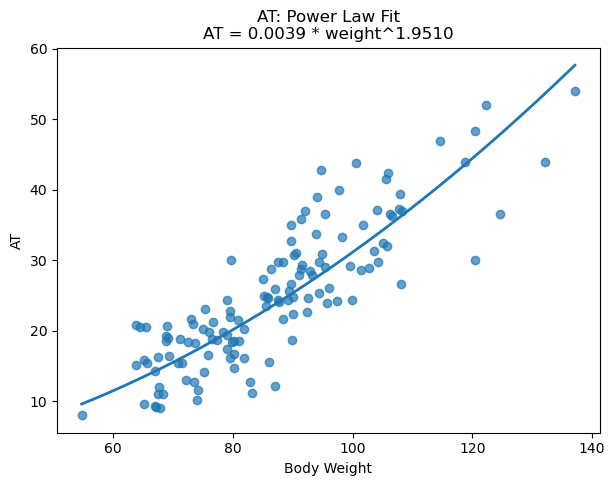

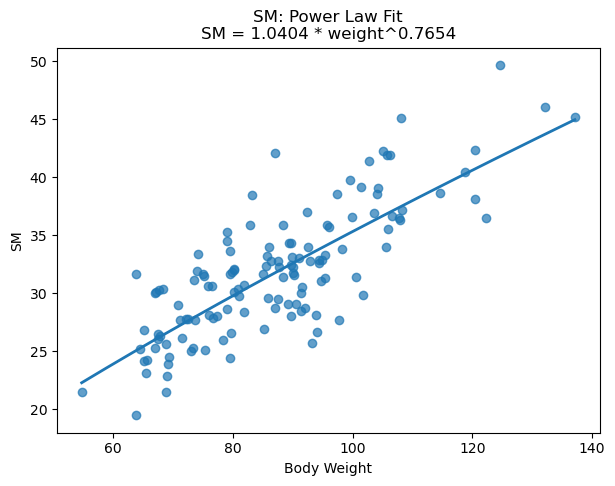

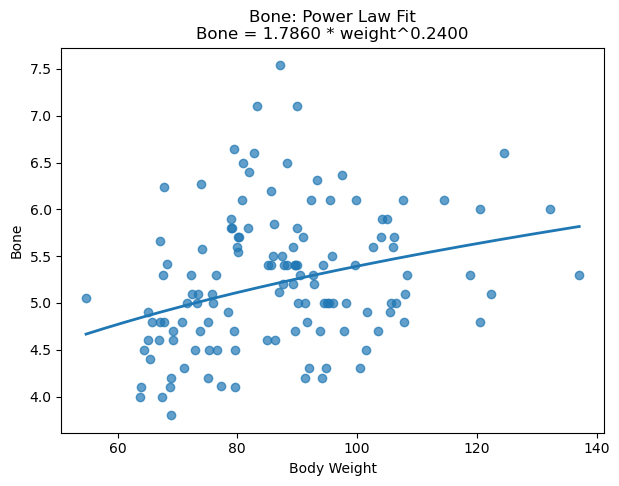

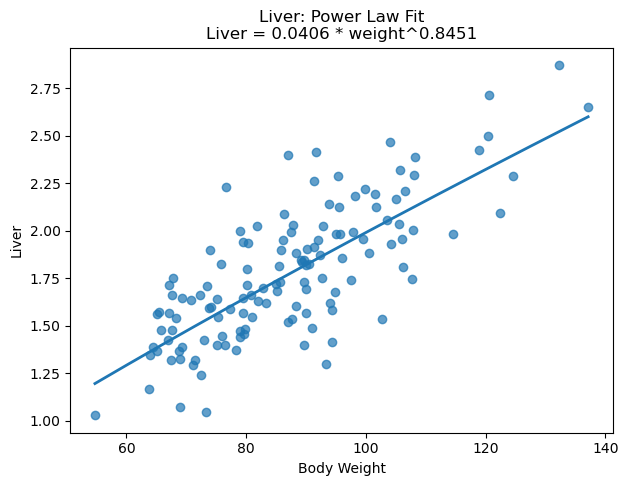

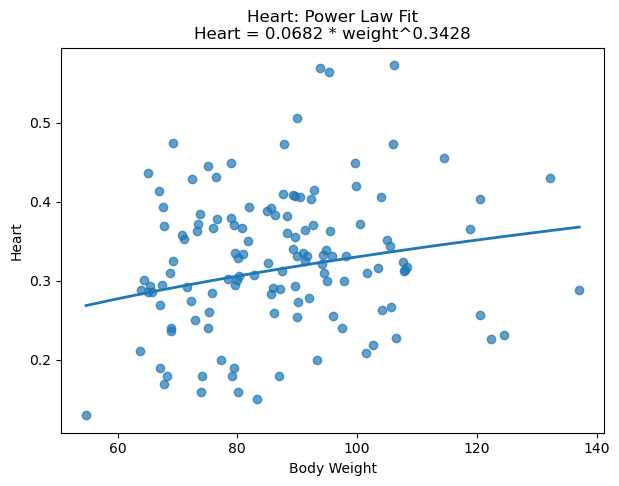

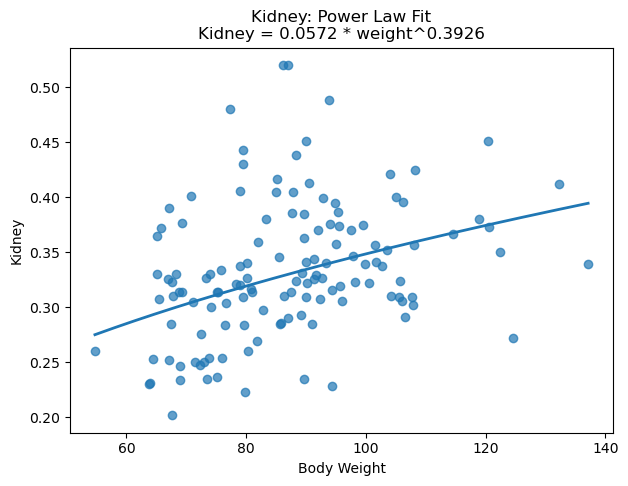

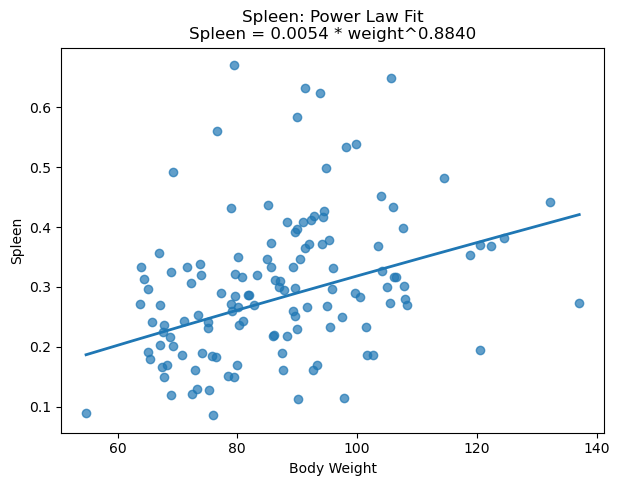

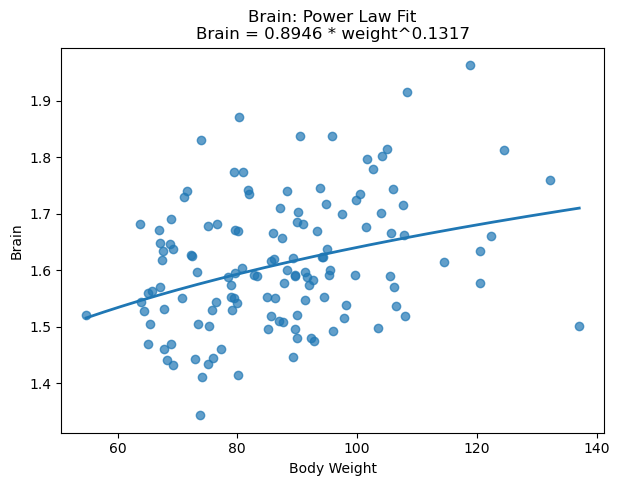

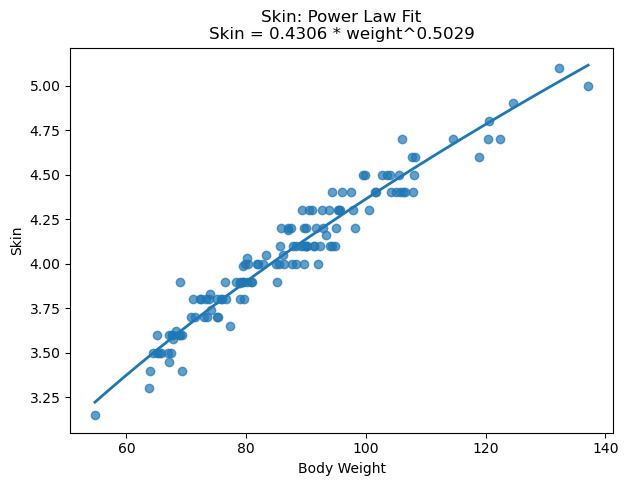

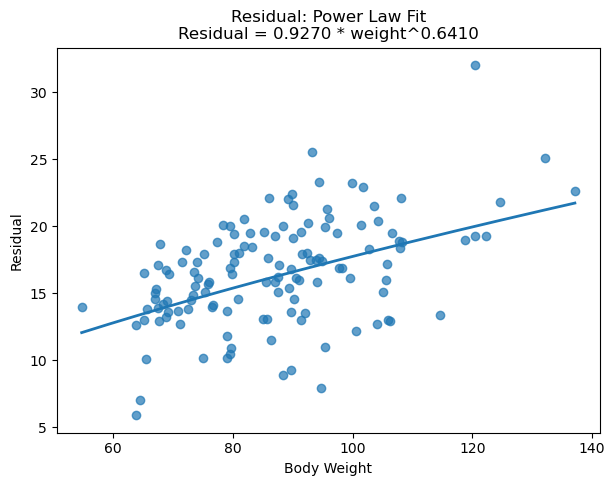

In [11]:
def plot_organ_power_law(organ):
    temp = cleaned_data[organ]
    result = summary_table[summary_table["organ"] == organ].iloc[0]

    alpha = result["alpha"]
    beta = result["beta"]

    x_grid = np.linspace(temp[weight_col].min(), temp[weight_col].max(), 200)
    y_grid = alpha * x_grid ** beta

    plt.figure(figsize=(7, 5))
    plt.scatter(temp[weight_col], temp[organ], alpha=0.7)
    plt.plot(x_grid, y_grid, linewidth=2)

    plt.xlabel("Body Weight")
    plt.ylabel(organ)
    plt.title(f"{organ}: Power Law Fit\n{organ} = {alpha:.4f} * weight^{beta:.4f}")
    plt.show()

for organ in organ_cols:
    plot_organ_power_law(organ)

### 13. Residual Plots for All organs

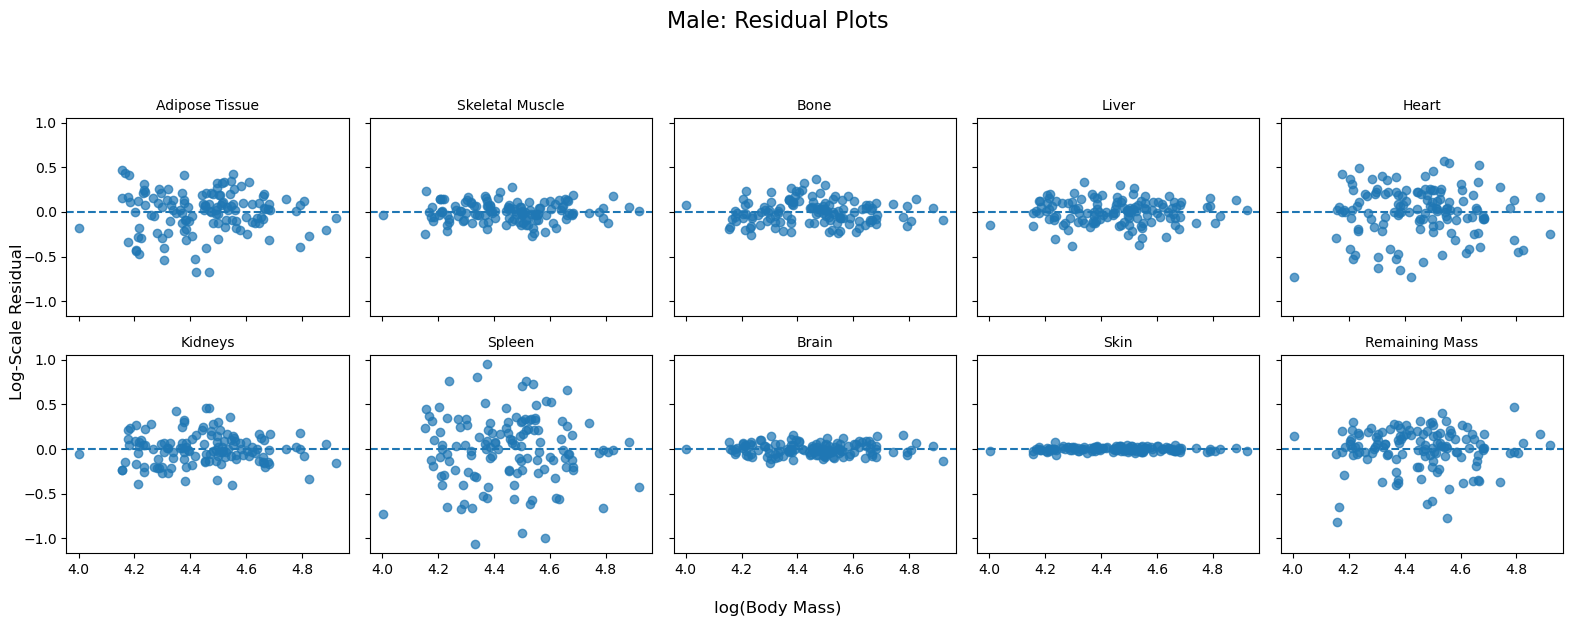

In [12]:
# ======================================================
# Residual plots as a 2x5 figure array
# Saves to current working directory
# ======================================================

import matplotlib.pyplot as plt

nrows = 2
ncols = 5

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 6),
    sharex=True,
    sharey=True
)

fig.suptitle(
    "Male: Residual Plots",
    fontsize=16,
    y=1.02
)

axes = axes.flatten()

for ax, organ in zip(axes, organ_cols):

    temp = cleaned_data[organ]

    ax.scatter(
        temp["log_x"],
        temp["log_residual"],
        alpha=0.7
    )

    ax.axhline(
        0,
        linestyle="--"
    )

    organ_label = organ_name_map.get(organ, organ)

    ax.set_title(
        organ_label,
        fontsize=10
    )

# Remove unused axes if needed
for ax in axes[len(organ_cols):]:
    fig.delaxes(ax)

# Shared axis labels
fig.supxlabel("log(Body Mass)")
fig.supylabel("Log-Scale Residual")

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

# Save in same folder
plt.savefig(
    "Figure_Residuals_All_Organs_Male.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 14. Q-Q Plots for all organs

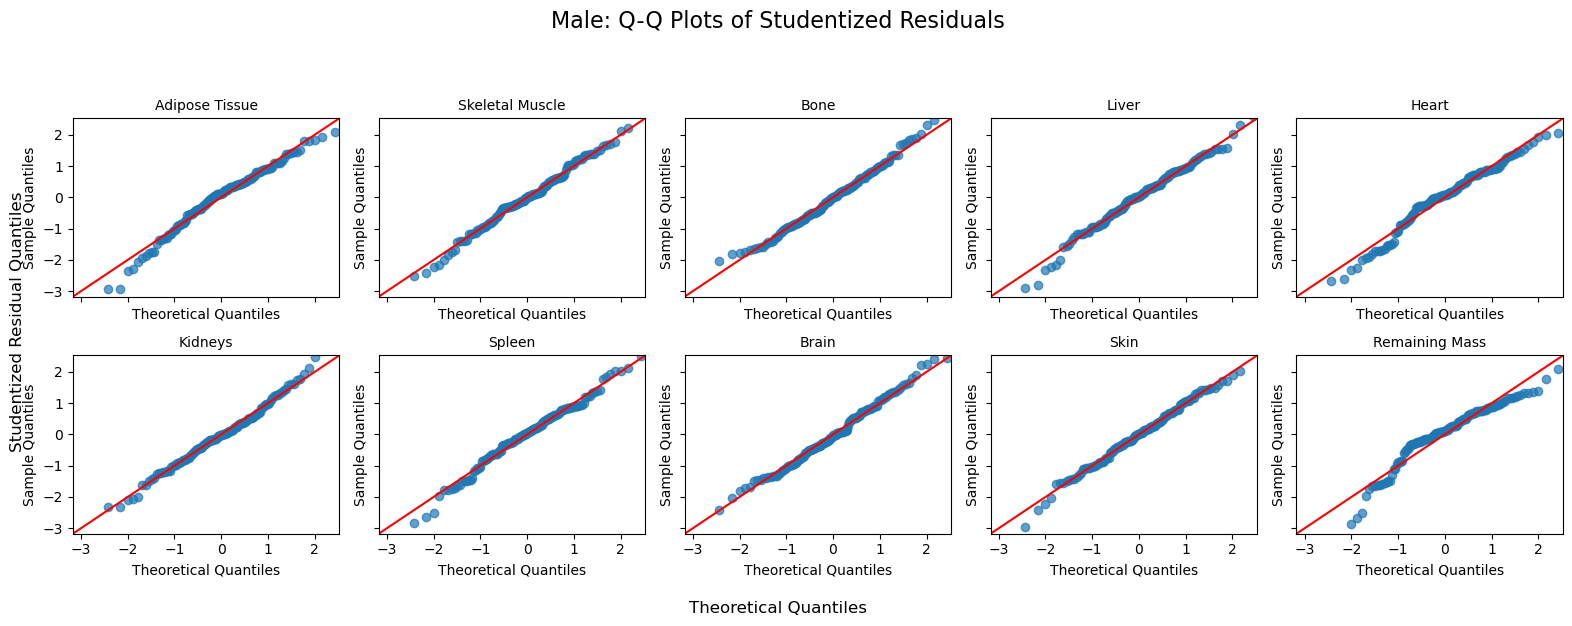

In [27]:
# ======================================================
# Q-Q plots as a 2x5 figure array
# Saves to current working directory
# ======================================================

import matplotlib.pyplot as plt
import statsmodels.api as sm

nrows = 2
ncols = 5

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 6),
    sharex=True,
    sharey=True
)

fig.suptitle(
    "Male: Q-Q Plots of Studentized Residuals",
    fontsize=16,
    y=1.02
)

axes = axes.flatten()

for ax, organ in zip(axes, organ_cols):

    model = models[organ]

    studentized_residuals = (
        model
        .get_influence()
        .resid_studentized_internal
    )

    sm.qqplot(
        studentized_residuals,
        line="45",
        ax=ax,
        marker='o',
        alpha=0.7
    )

    organ_label = organ_name_map.get(
        organ,
        organ
    )

    ax.set_title(
        organ_label,
        fontsize=10
    )

# Remove unused axes if needed
for ax in axes[len(organ_cols):]:
    fig.delaxes(ax)

# Shared axis labels
fig.supxlabel("Theoretical Quantiles")
fig.supylabel("Studentized Residual Quantiles")

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

# Save in same folder
plt.savefig(
    "Figure_QQPlots_All_Organs_Male.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 15. Correlation Plots for actual versus predicted organ masses. Some don't look so good.

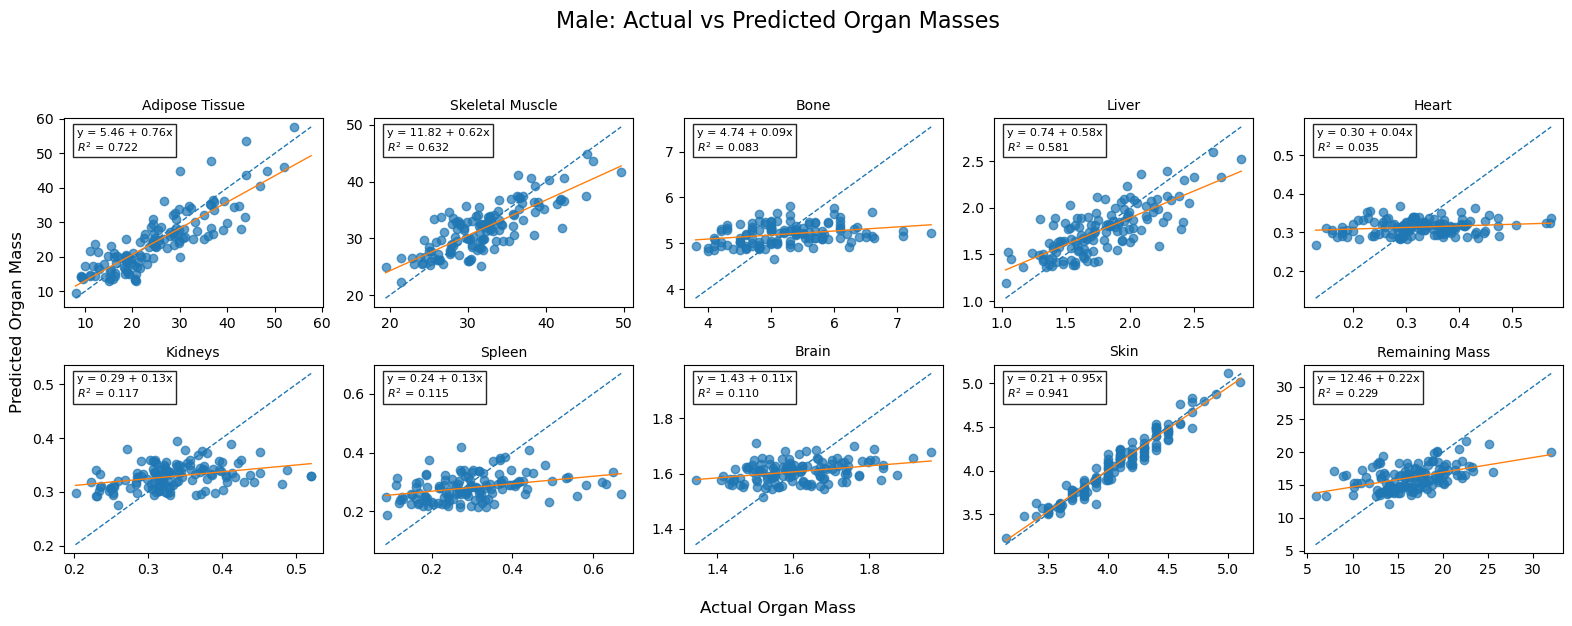

In [29]:
# ======================================================
# Actual vs predicted organ mass plots as a 2x5 figure array
# Saves to current working directory
# Females
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

nrows = 2
ncols = 5

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 6),
    sharex=False,
    sharey=False
)

fig.suptitle(
    "Male: Actual vs Predicted Organ Masses",
    fontsize=16,
    y=1.02
)

axes = axes.flatten()

for ax, organ in zip(axes, organ_cols):

    temp = cleaned_data[organ].copy()

    actual = temp[organ]
    predicted = temp["predicted_original"]

    X = sm.add_constant(actual)
    model = sm.OLS(predicted, X).fit()

    intercept = model.params["const"]
    slope = model.params[organ]
    r2 = model.rsquared

    xmin = min(actual.min(), predicted.min())
    xmax = max(actual.max(), predicted.max())

    xline = np.linspace(xmin, xmax, 200)
    yline = intercept + slope * xline

    ax.scatter(
        actual,
        predicted,
        alpha=0.7
    )

    ax.plot(
        [xmin, xmax],
        [xmin, xmax],
        linestyle="--",
        linewidth=1
    )

    ax.plot(
        xline,
        yline,
        linewidth=1
    )

    eq_text = (
        f"y = {intercept:.2f} + {slope:.2f}x\n"
        f"$R^2$ = {r2:.3f}"
    )

    ax.text(
        0.05,
        0.95,
        eq_text,
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=8,
        bbox=dict(
            boxstyle="square",
            facecolor="white",
            alpha=0.85
        )
    )

    organ_label = organ_name_map.get(organ, organ)

    ax.set_title(
        organ_label,
        fontsize=10
    )

# Remove unused axes if needed
for ax in axes[len(organ_cols):]:
    fig.delaxes(ax)

fig.supxlabel("Actual Organ Mass")
fig.supylabel("Predicted Organ Mass")

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    "Figure_Actual_vs_Predicted_All_Organs_Male.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 16. Bland Altman Plots for each organ

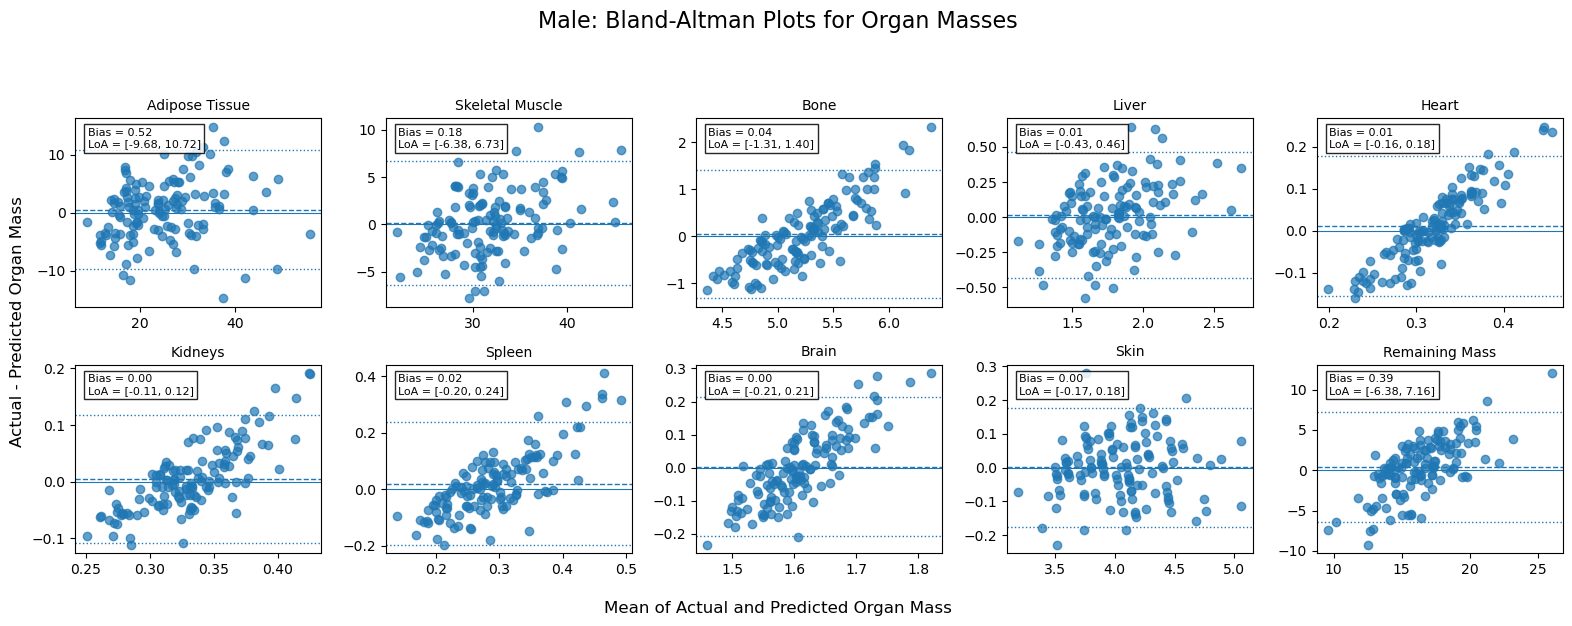

,organ,bias,sd_difference,loa_lower,loa_upper,proportional_bias_slope,proportional_bias_p
0,Adipose Tissue,0.519665,5.202479,-9.677194,10.716524,0.119724,1.806701e-02
1,Skeletal Muscle,0.175138,3.346129,-6.383274,6.733551,0.268912,1.039228e-05
2,Bone,0.043690,0.691875,-1.312386,1.399765,1.429498,3.279820e-36
3,Liver,0.014762,0.228516,-0.433129,0.462653,0.314883,2.029686e-06
4,Heart,0.011552,0.085307,-0.155650,0.178754,1.684700,1.740279e-51
5,Kidneys,0.004778,0.057971,-0.108844,0.118400,1.240212,7.733445e-28
6,Spleen,0.019413,0.111649,-0.199419,0.238245,1.232519,2.698894e-27
7,Brain,0.003504,0.107429,-0.207057,0.214065,1.347866,2.135379e-33
8,Skin,0.000901,0.089717,-0.174945,0.176747,0.022638,2.982362e-01
9,Remaining Mass,0.392479,3.453836,-6.377040,7.161999,0.935143,1.134601e-19


In [30]:
# ======================================================
# Bland-Altman organ mass plots as a 2x5 figure array
# Saves to current working directory
# Females
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

nrows = 2
ncols = 5

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 6),
    sharex=False,
    sharey=False
)

fig.suptitle(
    "Male: Bland-Altman Plots for Organ Masses",
    fontsize=16,
    y=1.02
)

axes = axes.flatten()

ba_summary_rows = []

for ax, organ in zip(axes, organ_cols):

    temp = cleaned_data[organ].copy()

    temp["difference"] = temp[organ] - temp["predicted_original"]
    temp["mean_measurement"] = (
        temp[organ] + temp["predicted_original"]
    ) / 2

    bias = temp["difference"].mean()
    sd_diff = temp["difference"].std(ddof=1)

    loa_upper = bias + 1.96 * sd_diff
    loa_lower = bias - 1.96 * sd_diff

    X_ba = sm.add_constant(temp["mean_measurement"])
    ba_model = sm.OLS(temp["difference"], X_ba).fit()

    slope = ba_model.params["mean_measurement"]
    p_slope = ba_model.pvalues["mean_measurement"]

    organ_label = organ_name_map.get(organ, organ)

    ba_summary_rows.append({
        "organ": organ_label,
        "bias": bias,
        "sd_difference": sd_diff,
        "loa_lower": loa_lower,
        "loa_upper": loa_upper,
        "proportional_bias_slope": slope,
        "proportional_bias_p": p_slope
    })

    ax.scatter(
        temp["mean_measurement"],
        temp["difference"],
        alpha=0.7
    )

    ax.axhline(
        bias,
        linestyle="--",
        linewidth=1
    )

    ax.axhline(
        loa_upper,
        linestyle=":",
        linewidth=1
    )

    ax.axhline(
        loa_lower,
        linestyle=":",
        linewidth=1
    )

    ax.axhline(
        0,
        linewidth=0.8
    )

    ax.set_title(
        organ_label,
        fontsize=10
    )

    ax.text(
        0.05,
        0.95,
        f"Bias = {bias:.2f}\nLoA = [{loa_lower:.2f}, {loa_upper:.2f}]",
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=8,
        bbox=dict(
            boxstyle="square",
            facecolor="white",
            alpha=0.85
        )
    )

# Remove unused axes if needed
for ax in axes[len(organ_cols):]:
    fig.delaxes(ax)

fig.supxlabel("Mean of Actual and Predicted Organ Mass")
fig.supylabel("Actual - Predicted Organ Mass")

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    "Figure_BlandAltman_All_Organs_Male.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ba_summary = pd.DataFrame(ba_summary_rows)
display(ba_summary)

### 17. Forest Plot of $\beta_i$ (scaling exponents) for each organ

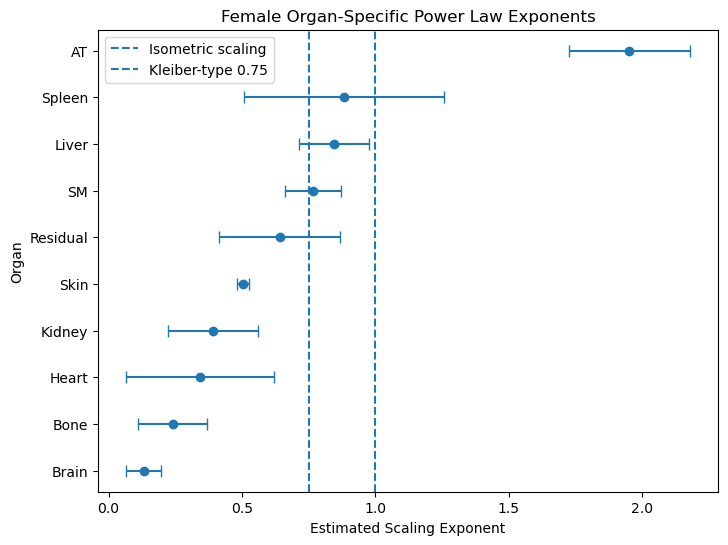

In [16]:
plot_df = summary_table.sort_values("beta")

plt.figure(figsize=(8, 6))

plt.errorbar(
    x=plot_df["beta"],
    y=plot_df["organ"],
    xerr=[
        plot_df["beta"] - plot_df["beta_ci_lower"],
        plot_df["beta_ci_upper"] - plot_df["beta"]
    ],
    fmt="o",
    capsize=4
)

plt.axvline(1.0, linestyle="--", label="Isometric scaling")
plt.axvline(0.75, linestyle="--", label="Kleiber-type 0.75")

plt.xlabel("Estimated Scaling Exponent")
plt.ylabel("Organ")
plt.title("Female Organ-Specific Power Law Exponents")
plt.legend()
plt.show()

### 18. Next we compute the mass fractions.


,organ,mean_mass_fraction,sd_mass_fraction,min_mass_fraction,max_mass_fraction
0,Skeletal Muscle,0.368508,0.042045,0.275174,0.495280
1,Adipose Tissue,0.279281,0.072999,0.133814,0.451586
2,Remaining Mass,0.192470,0.041403,0.083354,0.275572
3,Bone,0.061670,0.011438,0.038638,0.092254
4,Skin,0.047298,0.004214,0.036451,0.057545
5,Liver,0.020566,0.002728,0.013941,0.029144
6,Brain,0.019009,0.003145,0.010943,0.027768
7,Kidneys,0.003907,0.000808,0.002184,0.006206
8,Heart,0.003818,0.001104,0.001802,0.006854
9,Spleen,0.003472,0.001307,0.001130,0.008425


Sum of mean mass fractions:
0.9999999999999999


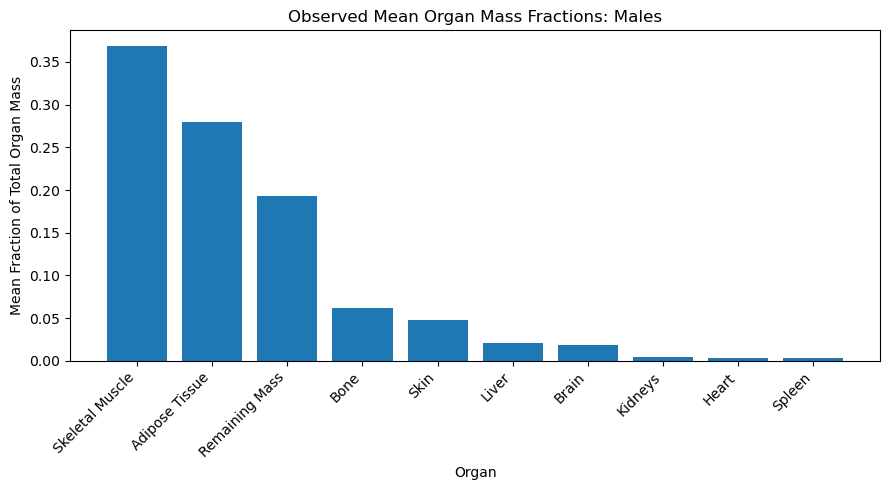

,weight,total_organ_mass,AT_mass_fraction,SM_mass_fraction,Bone_mass_fraction,Liver_mass_fraction,Heart_mass_fraction,Kidney_mass_fraction,Spleen_mass_fraction,Brain_mass_fraction,Skin_mass_fraction,Residual_mass_fraction
0,68.99,69.009,0.299961,0.331116,0.055065,0.015563,0.003478,0.003391,0.001739,0.024504,0.056514,0.208668
1,63.76,63.731,0.326372,0.305503,0.062764,0.018327,0.003311,0.003609,0.004252,0.026376,0.051780,0.197706
2,67.49,67.425,0.241750,0.386207,0.059325,0.019577,0.004375,0.004227,0.002477,0.023997,0.051910,0.206155
3,63.87,63.883,0.236370,0.495280,0.064180,0.021085,0.004508,0.003616,0.005228,0.024154,0.053222,0.092356
4,68.80,68.908,0.268474,0.372235,0.059500,0.019882,0.004499,0.004557,0.003149,0.023901,0.052244,0.191560


In [17]:
# ======================================================
# Observed organ mass fractions
# f_i = M_i / sum_j M_j
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Build dataframe from observed organ masses
# ------------------------------------------------------

mass_fraction_df = organ_df[[weight_col] + organ_cols].copy()

for col in [weight_col] + organ_cols:
    mass_fraction_df[col] = pd.to_numeric(
        mass_fraction_df[col],
        errors="coerce"
    )

mass_fraction_df = mass_fraction_df.replace(
    [np.inf, -np.inf],
    np.nan
)

mass_fraction_df = mass_fraction_df.dropna()

# Keep only positive body weight and positive organ masses

mass_fraction_df = mass_fraction_df[
    mass_fraction_df[weight_col] > 0
].copy()

for organ in organ_cols:
    mass_fraction_df = mass_fraction_df[
        mass_fraction_df[organ] > 0
    ].copy()

# ------------------------------------------------------
# Compute total observed organ mass and mass fractions
# ------------------------------------------------------

mass_fraction_df["total_organ_mass"] = (
    mass_fraction_df[organ_cols].sum(axis=1)
)

for organ in organ_cols:
    mass_fraction_df[f"{organ}_mass_fraction"] = (
        mass_fraction_df[organ] /
        mass_fraction_df["total_organ_mass"]
    )

# ------------------------------------------------------
# Summarize mean mass fractions
# ------------------------------------------------------

mean_mass_fractions = []

for organ in organ_cols:
    mean_mass_fractions.append({
        "organ": organ_name_map.get(organ, organ),
        "mean_mass_fraction": mass_fraction_df[f"{organ}_mass_fraction"].mean(),
        "sd_mass_fraction": mass_fraction_df[f"{organ}_mass_fraction"].std(ddof=1),
        "min_mass_fraction": mass_fraction_df[f"{organ}_mass_fraction"].min(),
        "max_mass_fraction": mass_fraction_df[f"{organ}_mass_fraction"].max()
    })

mean_mass_fractions = pd.DataFrame(mean_mass_fractions)

mean_mass_fractions = mean_mass_fractions.sort_values(
    "mean_mass_fraction",
    ascending=False
).reset_index(drop=True)

display(mean_mass_fractions)

print("Sum of mean mass fractions:")
print(mean_mass_fractions["mean_mass_fraction"].sum())

# ------------------------------------------------------
# Plot mean observed organ mass fractions
# ------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    mean_mass_fractions["organ"],
    mean_mass_fractions["mean_mass_fraction"]
)

plt.ylabel("Mean Fraction of Total Organ Mass")
plt.xlabel("Organ")
plt.title("Observed Mean Organ Mass Fractions: Males")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# Preview participant-level mass fractions
# ------------------------------------------------------

display(
    mass_fraction_df[
        [weight_col, "total_organ_mass"]
        + [f"{organ}_mass_fraction" for organ in organ_cols]
    ].head()
)

### 20. Visualization of mass fraction

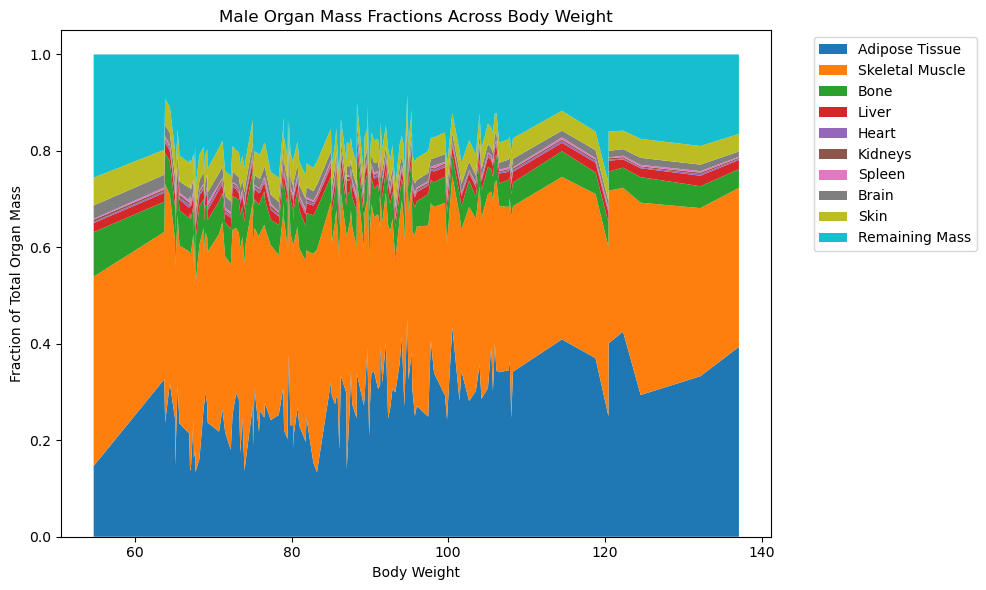

In [18]:
# ======================================================
# Stackplot of observed organ mass fractions across body weight
# ======================================================

mass_fraction_columns = [
    f"{organ}_mass_fraction"
    for organ in organ_cols
]

mass_fraction_df_sorted = mass_fraction_df.sort_values(weight_col)

plt.figure(figsize=(10, 6))

plt.stackplot(
    mass_fraction_df_sorted[weight_col],
    [
        mass_fraction_df_sorted[col]
        for col in mass_fraction_columns
    ],
    labels=[
        organ_name_map[organ]
        for organ in organ_cols
    ]
)

plt.xlabel("Body Weight")
plt.ylabel("Fraction of Total Organ Mass")
plt.title("Male Organ Mass Fractions Across Body Weight")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

### 21. Di's $w_i(M)$ which represent the weights for each organ $\beta_i$. The weights represent the fraction of total REE contributed by organ or tissue compartment.

In [19]:
# ======================================================
# Model-derived metabolic contribution weights
# All organs modeled as power laws
#
# w_i(M) = K_i alpha_i M^beta_i / sum_j K_j alpha_j M^beta_j
# ======================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------
# Elia coefficients
# ------------------------------------------------------

elia_k = {
    "AT": 4.5,
    "SM": 13,
    "Bone": 12,
    "Liver": 200,
    "heart": 440,
    "Kidney": 440,
    "Spleen": 12,
    "Brain": 240,
    "Skin": 12,
    "Residual": 12
}

# ------------------------------------------------------
# Build model-derived weight dataframe
# ------------------------------------------------------

model_weight_df = organ_df[[weight_col] + organ_cols].copy()

for col in [weight_col] + organ_cols:
    model_weight_df[col] = pd.to_numeric(
        model_weight_df[col],
        errors="coerce"
    )

model_weight_df = model_weight_df.replace([np.inf, -np.inf], np.nan)
model_weight_df = model_weight_df.dropna()
model_weight_df = model_weight_df[model_weight_df[weight_col] > 0].copy()

# ------------------------------------------------------
# Compute model-predicted organ MR terms
# K_i alpha_i M^beta_i
# ------------------------------------------------------

#Define Elia's weights
# ======================================================
# Elia tissue-specific metabolic rate coefficients
# kcal/kg/day
# ======================================================

elia_k = {
    "AT": 4.5,
    "SM": 13,
    "Bone": 12,
    "Liver": 200,
    "Heart": 440,
    "Kidney": 440,
    "Spleen": 12,
    "Brain": 240,
    "Skin": 12,
    "Residual": 12
}
model_weight_df["total_model_mr"] = 0.0

for organ in organ_cols:

    row = summary_table[
        summary_table["organ"] == organ
    ]

    if row.empty:
        raise ValueError(f"{organ} not found in summary_table.")

    alpha_i = row["alpha"].iloc[0]
    beta_i = row["beta"].iloc[0]
    K_i = elia_k[organ]

    model_weight_df[f"{organ}_model_mr"] = (
        K_i
        * alpha_i
        * model_weight_df[weight_col] ** beta_i
    )

    model_weight_df["total_model_mr"] += model_weight_df[f"{organ}_model_mr"]

# ------------------------------------------------------
# Compute w_i(M)
# ------------------------------------------------------

for organ in organ_cols:
    model_weight_df[f"{organ}_w"] = (
        model_weight_df[f"{organ}_model_mr"]
        / model_weight_df["total_model_mr"]
    )

# ------------------------------------------------------
# Mean model-derived weights
# ------------------------------------------------------

mean_model_weights = pd.DataFrame({
    "organ": [
        organ_name_map.get(organ, organ)
        for organ in organ_cols
    ],
    "mean_weight": [
        model_weight_df[f"{organ}_w"].mean()
        for organ in organ_cols
    ]
})

mean_model_weights = mean_model_weights.sort_values(
    "mean_weight",
    ascending=False
).reset_index(drop=True)

display(mean_model_weights)

print("Sum of mean model-derived weights:")
print(mean_model_weights["mean_weight"].sum())

,organ,mean_weight
0,Skeletal Muscle,0.221647
1,Brain,0.210249
2,Liver,0.189937
3,Remaining Mass,0.104747
4,Kidneys,0.078462
5,Heart,0.074974
6,Adipose Tissue,0.057914
7,Bone,0.033939
8,Skin,0.026320
9,Spleen,0.001812


Sum of mean model-derived weights:
1.0


### 24. Visualization of organ weights (fraction of contribution to REE)

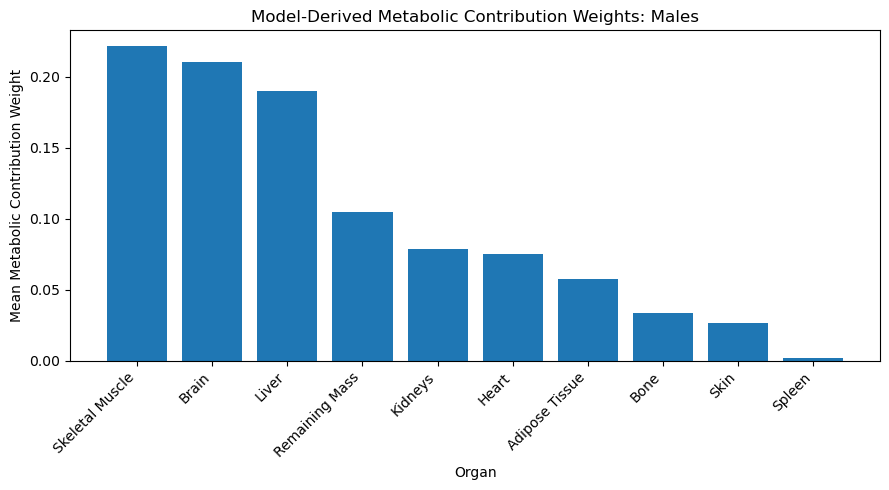

In [20]:
plt.figure(figsize=(9, 5))

plt.bar(
    mean_model_weights["organ"],
    mean_model_weights["mean_weight"]
)

plt.ylabel("Mean Metabolic Contribution Weight")
plt.xlabel("Organ")
plt.title("Model-Derived Metabolic Contribution Weights: Males")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 25. I feel I did this but I need big $\beta$

In [21]:
# ======================================================
# Chunk
# Direct whole-body REE power law
#
# REE = alpha * M^beta
#
# This is the observed (direct) whole-body scaling exponent
# used later for comparison with the effective beta derived
# from the organ model.
# ======================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm

# ------------------------------------------------------
# Column names
# ------------------------------------------------------

weight_col = "weight"
ree_col = "RMR-measured"

# ------------------------------------------------------
# Keep only positive, non-missing observations
# ------------------------------------------------------

ree_df = df[[weight_col, ree_col]].copy()

ree_df[weight_col] = pd.to_numeric(
    ree_df[weight_col],
    errors="coerce"
)

ree_df[ree_col] = pd.to_numeric(
    ree_df[ree_col],
    errors="coerce"
)

ree_df = ree_df.replace(
    [np.inf, -np.inf],
    np.nan
)

ree_df = ree_df.dropna()

ree_df = ree_df[
    (ree_df[weight_col] > 0)
    & (ree_df[ree_col] > 0)
].copy()

# ------------------------------------------------------
# Natural log transform
# ------------------------------------------------------

ree_df["ln_M"] = np.log(
    ree_df[weight_col]
)

ree_df["ln_REE"] = np.log(
    ree_df[ree_col]
)

# ------------------------------------------------------
# Fit log-log power law
# ------------------------------------------------------

X = sm.add_constant(
    ree_df["ln_M"]
)

y = ree_df["ln_REE"]

ree_power_model = sm.OLS(
    y,
    X
).fit()

print(ree_power_model.summary())

# ------------------------------------------------------
# Extract parameters
# ------------------------------------------------------

ln_alpha_REE_direct = (
    ree_power_model.params["const"]
)

beta_REE_direct = (
    ree_power_model.params["ln_M"]
)

alpha_REE_direct = np.exp(
    ln_alpha_REE_direct
)

# ------------------------------------------------------
# Confidence intervals
# ------------------------------------------------------

ci = ree_power_model.conf_int()

ln_alpha_ci_lower = ci.loc["const", 0]
ln_alpha_ci_upper = ci.loc["const", 1]

beta_REE_direct_ci_lower = ci.loc["ln_M", 0]
beta_REE_direct_ci_upper = ci.loc["ln_M", 1]

alpha_REE_direct_ci_lower = np.exp(
    ln_alpha_ci_lower
)

alpha_REE_direct_ci_upper = np.exp(
    ln_alpha_ci_upper
)

# ------------------------------------------------------
# Print results
# ------------------------------------------------------

print("\nPower-law model:")
print("REE = alpha * M^beta")

print("\nParameter estimates:")

print(
    f"alpha = {alpha_REE_direct:.6f}"
)

print(
    f"95% CI for alpha = "
    f"({alpha_REE_direct_ci_lower:.6f}, "
    f"{alpha_REE_direct_ci_upper:.6f})"
)

print(
    f"\nbeta = {beta_REE_direct:.6f}"
)

print(
    f"95% CI for beta = "
    f"({beta_REE_direct_ci_lower:.6f}, "
    f"{beta_REE_direct_ci_upper:.6f})"
)

print(
    f"\nR-squared = "
    f"{ree_power_model.rsquared:.6f}"
)

print(
    f"Adjusted R-squared = "
    f"{ree_power_model.rsquared_adj:.6f}"
)

print(
    f"Number of observations = "
    f"{len(ree_df)}"
)

# ------------------------------------------------------
# Predicted REE on original scale
# ------------------------------------------------------

ree_df["REE_predicted"] = (
    alpha_REE_direct
    * ree_df[weight_col] ** beta_REE_direct
)

# ------------------------------------------------------
# Save direct REE scaling results
# ------------------------------------------------------

ree_power_results = {
    "alpha_REE_direct": alpha_REE_direct,
    "alpha_REE_direct_ci_lower": alpha_REE_direct_ci_lower,
    "alpha_REE_direct_ci_upper": alpha_REE_direct_ci_upper,
    "beta_REE_direct": beta_REE_direct,
    "beta_REE_direct_ci_lower": beta_REE_direct_ci_lower,
    "beta_REE_direct_ci_upper": beta_REE_direct_ci_upper,
    "r_squared": ree_power_model.rsquared,
    "adj_r_squared": ree_power_model.rsquared_adj,
    "n": len(ree_df)
}

display(
    pd.DataFrame(
        [ree_power_results]
    )
)

display(
    ree_df.head()
)

                            OLS Regression Results                            
Dep. Variable:                 ln_REE   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     278.9
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           4.74e-34
Time:                        07:59:17   Log-Likelihood:                 149.33
No. Observations:                 131   AIC:                            -294.7
Df Residuals:                     129   BIC:                            -288.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.5995      0.173     26.539      0.0

,alpha_REE_direct,alpha_REE_direct_ci_lower,alpha_REE_direct_ci_upper,beta_REE_direct,beta_REE_direct_ci_lower,beta_REE_direct_ci_upper,r_squared,adj_r_squared,n
0,99.434646,70.569637,140.106274,0.649822,0.572842,0.726801,0.683782,0.68133,131


,weight,RMR-measured,ln_M,ln_REE,REE_predicted
0,68.99,1464,4.233962,7.288928,1557.474729
1,63.76,1392,4.155126,7.238497,1479.696059
2,67.49,1610,4.211979,7.383989,1535.385180
3,63.87,1597,4.156850,7.375882,1481.354423
4,68.80,1735,4.231204,7.458763,1554.686090


### 26. Bland Atlmans for REE predicted by organs versus REE measured

Female Bland-Altman: measured REE - organ-model predicted REE
n = 131
Mean measured REE = 1810.44
Mean predicted REE = 1852.49
Bias = -42.05
Lower LOA = -314.97
Upper LOA = 230.86


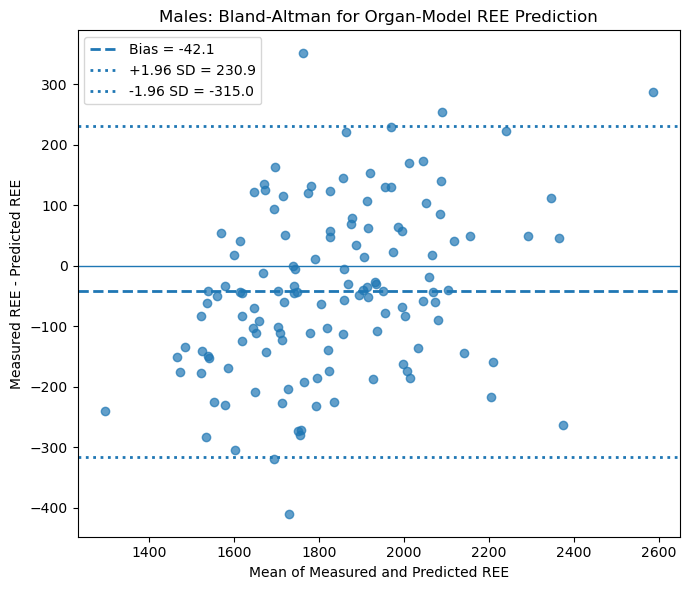

,weight,RMR-measured,REE_pred_powerlaw_organs,Adipose Tissue REE_hat,Skeletal Muscle REE_hat,Bone REE_hat,Liver REE_hat,Heart REE_hat,Kidneys REE_hat,Spleen REE_hat,Brain REE_hat,Skin REE_hat,Remaining Mass REE_hat
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,87.048779,1810.435115,1852.489827,110.110667,411.730529,62.415268,353.369703,138.149019,144.713161,3.373909,385.867833,48.646896,194.112842
std,15.609791,251.365382,205.806199,39.619939,56.200336,2.643341,53.354141,8.372536,10.055646,0.533356,8.949891,4.338917,22.129603
min,54.750000,1177.000000,1416.739523,43.278917,289.530417,56.001216,239.292615,118.261338,121.073773,2.242874,363.660038,38.678481,144.719853
25%,75.070000,1615.500000,1695.007351,80.118122,368.651501,60.407537,312.448410,131.773680,137.047824,2.964753,379.090640,45.332350,177.172534
50%,87.000000,1798.000000,1853.333643,106.831910,412.706773,62.583662,353.923776,138.606381,145.218169,3.377633,386.523496,48.822552,194.739291
75%,95.380000,1966.500000,1963.330123,127.826886,442.802333,63.980014,382.526582,143.044861,150.557249,3.663688,391.231591,51.133482,206.563436
max,137.100000,2729.000000,2506.646339,259.459034,584.548601,69.800186,519.796674,161.988407,173.608802,5.049199,410.374186,61.369501,260.651750


In [22]:
# ======================================================
# Bland-Altman: measured REE vs organ-model predicted REE
#
# Predicted REE = sum_i K_i alpha_i M^beta_i
# Uses alpha_i and beta_i from summary_table
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Build participant-level dataframe
# ------------------------------------------------------

ree_ba_df = organ_df[[weight_col, ree_col] + organ_cols].copy()

for col in [weight_col, ree_col] + organ_cols:
    ree_ba_df[col] = pd.to_numeric(
        ree_ba_df[col],
        errors="coerce"
    )

ree_ba_df = ree_ba_df.replace(
    [np.inf, -np.inf],
    np.nan
)

ree_ba_df = ree_ba_df.dropna()

ree_ba_df = ree_ba_df[
    (ree_ba_df[weight_col] > 0)
    & (ree_ba_df[ree_col] > 0)
].copy()

for organ in organ_cols:
    ree_ba_df = ree_ba_df[
        ree_ba_df[organ] > 0
    ].copy()

# ------------------------------------------------------
# Predicted REE from organ power-law model
# REE_hat = sum_i K_i alpha_i M^beta_i
# ------------------------------------------------------

ree_ba_df["REE_pred_powerlaw_organs"] = 0.0

for organ in organ_cols:

    row = summary_table[
        summary_table["organ"] == organ
    ]

    if row.empty:
        raise ValueError(
            f"{organ} not found in summary_table. "
            "Make sure summary_table uses raw organ column names."
        )

    alpha_i = row["alpha"].iloc[0]
    beta_i = row["beta"].iloc[0]
    K_i = elia_k[organ]

    ree_ba_df[f"{organ}_mass_hat"] = (
        alpha_i
        * ree_ba_df[weight_col] ** beta_i
    )

    ree_ba_df[f"{organ_name_map[organ]} REE_hat"] = (
        K_i
        * ree_ba_df[f"{organ}_mass_hat"]
    )

    ree_ba_df["REE_pred_powerlaw_organs"] += (
        ree_ba_df[f"{organ_name_map[organ]} REE_hat"]
    )

# ------------------------------------------------------
# Bland-Altman calculations
# ------------------------------------------------------

ree_ba_df["ba_mean"] = (
    ree_ba_df[ree_col]
    + ree_ba_df["REE_pred_powerlaw_organs"]
) / 2

ree_ba_df["ba_diff"] = (
    ree_ba_df[ree_col]
    - ree_ba_df["REE_pred_powerlaw_organs"]
)

bias = ree_ba_df["ba_diff"].mean()
sd_diff = ree_ba_df["ba_diff"].std(ddof=1)

loa_upper = bias + 1.96 * sd_diff
loa_lower = bias - 1.96 * sd_diff

# ------------------------------------------------------
# Print results
# ------------------------------------------------------

print("Female Bland-Altman: measured REE - organ-model predicted REE")
print(f"n = {len(ree_ba_df)}")
print(f"Mean measured REE = {ree_ba_df[ree_col].mean():.2f}")
print(f"Mean predicted REE = {ree_ba_df['REE_pred_powerlaw_organs'].mean():.2f}")
print(f"Bias = {bias:.2f}")
print(f"Lower LOA = {loa_lower:.2f}")
print(f"Upper LOA = {loa_upper:.2f}")

# ------------------------------------------------------
# Plot
# ------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.scatter(
    ree_ba_df["ba_mean"],
    ree_ba_df["ba_diff"],
    alpha=0.7
)

plt.axhline(
    bias,
    linestyle="--",
    linewidth=2,
    label=f"Bias = {bias:.1f}"
)

plt.axhline(
    loa_upper,
    linestyle=":",
    linewidth=2,
    label=f"+1.96 SD = {loa_upper:.1f}"
)

plt.axhline(
    loa_lower,
    linestyle=":",
    linewidth=2,
    label=f"-1.96 SD = {loa_lower:.1f}"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Mean of Measured and Predicted REE")
plt.ylabel("Measured REE - Predicted REE")
plt.title("Males: Bland-Altman for Organ-Model REE Prediction")

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# Optional: display organ REE components with mapped names
# ------------------------------------------------------

component_cols = [
    f"{organ_name_map[organ]} REE_hat"
    for organ in organ_cols
]

display(
    ree_ba_df[
        [weight_col, ree_col, "REE_pred_powerlaw_organs"]
        + component_cols
    ].describe()
)

### 27. Correlation between Actual versus Predicted REE

Male organ power-law parameters used in REE reconstruction


,Organ,alpha,beta,K,organ_mass_R2
0,Adipose Tissue,0.003903,1.951050,4.5,0.690912
1,Skeletal Muscle,1.040409,0.765393,13.0,0.618792
2,Bone,1.785999,0.239956,12.0,0.095981
3,Liver,0.040624,0.845106,200.0,0.562526
4,Heart,0.068163,0.342757,440.0,0.044868
5,Kidneys,0.057156,0.392626,440.0,0.140236
6,Spleen,0.005431,0.884020,12.0,0.144601
7,Brain,0.894579,0.131654,240.0,0.109476
8,Skin,0.430579,0.502901,12.0,0.940502
9,Remaining Mass,0.926960,0.640989,12.0,0.194432



Male actual vs predicted REE
n = 131
Mean measured REE = 1810.44
Mean predicted REE = 1852.49
Mean difference measured - predicted = -42.05
R^2 actual vs predicted = 0.6933


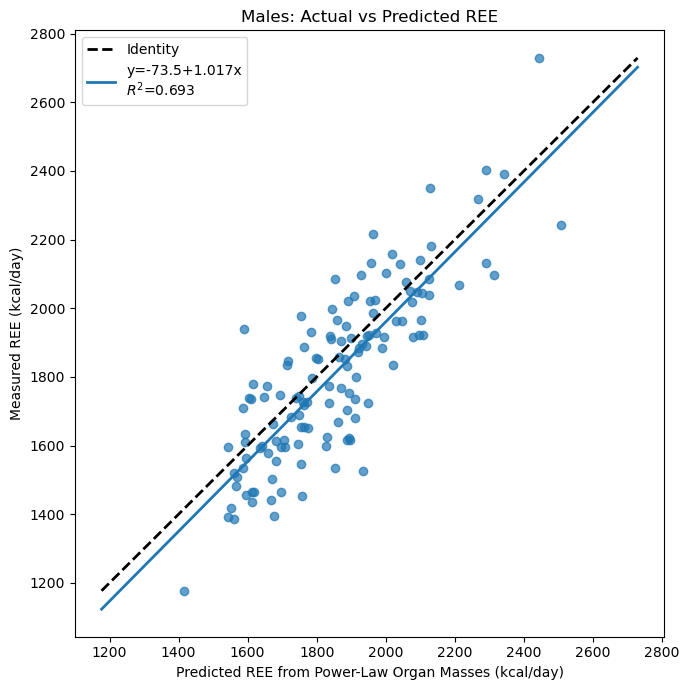

,weight,RMR-measured,REE_pred_powerlaw_organs,Adipose Tissue REE_hat,Skeletal Muscle REE_hat,Bone REE_hat,Liver REE_hat,Heart REE_hat,Kidneys REE_hat,Spleen REE_hat,Brain REE_hat,Skin REE_hat,Remaining Mass REE_hat
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,87.048779,1810.435115,1852.489827,110.110667,411.730529,62.415268,353.369703,138.149019,144.713161,3.373909,385.867833,48.646896,194.112842
std,15.609791,251.365382,205.806199,39.619939,56.200336,2.643341,53.354141,8.372536,10.055646,0.533356,8.949891,4.338917,22.129603
min,54.750000,1177.000000,1416.739523,43.278917,289.530417,56.001216,239.292615,118.261338,121.073773,2.242874,363.660038,38.678481,144.719853
25%,75.070000,1615.500000,1695.007351,80.118122,368.651501,60.407537,312.448410,131.773680,137.047824,2.964753,379.090640,45.332350,177.172534
50%,87.000000,1798.000000,1853.333643,106.831910,412.706773,62.583662,353.923776,138.606381,145.218169,3.377633,386.523496,48.822552,194.739291
75%,95.380000,1966.500000,1963.330123,127.826886,442.802333,63.980014,382.526582,143.044861,150.557249,3.663688,391.231591,51.133482,206.563436
max,137.100000,2729.000000,2506.646339,259.459034,584.548601,69.800186,519.796674,161.988407,173.608802,5.049199,410.374186,61.369501,260.651750


In [23]:
# ======================================================
# Actual vs predicted REE
#
# Predicted REE = sum_i K_i * alpha_i * M^beta_i
#
# Uses organ alpha_i and beta_i from summary_table
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ------------------------------------------------------
# Build participant-level dataframe
# ------------------------------------------------------

ree_pred_df = organ_df[[weight_col, ree_col] + organ_cols].copy()

for col in [weight_col, ree_col] + organ_cols:
    ree_pred_df[col] = pd.to_numeric(
        ree_pred_df[col],
        errors="coerce"
    )

ree_pred_df = ree_pred_df.replace(
    [np.inf, -np.inf],
    np.nan
)

ree_pred_df = ree_pred_df.dropna()

ree_pred_df = ree_pred_df[
    (ree_pred_df[weight_col] > 0)
    & (ree_pred_df[ree_col] > 0)
].copy()

for organ in organ_cols:
    ree_pred_df = ree_pred_df[
        ree_pred_df[organ] > 0
    ].copy()

# ------------------------------------------------------
# Predict REE from organ power laws
# ------------------------------------------------------

ree_pred_df["REE_pred_powerlaw_organs"] = 0.0

params_rows = []

for organ in organ_cols:

    row = summary_table[
        summary_table["organ"] == organ
    ]

    if row.empty:
        raise ValueError(
            f"{organ} not found in summary_table. "
            "summary_table must contain raw organ column names."
        )

    alpha_i = row["alpha"].iloc[0]
    beta_i = row["beta"].iloc[0]
    r2_i = row["r_squared"].iloc[0]
    K_i = elia_k[organ]

    organ_label = organ_name_map.get(organ, organ)

    ree_pred_df[f"{organ}_mass_hat"] = (
        alpha_i
        * ree_pred_df[weight_col] ** beta_i
    )

    ree_pred_df[f"{organ_label} REE_hat"] = (
        K_i
        * ree_pred_df[f"{organ}_mass_hat"]
    )

    ree_pred_df["REE_pred_powerlaw_organs"] += (
        ree_pred_df[f"{organ_label} REE_hat"]
    )

    params_rows.append({
        "Organ": organ_label,
        "alpha": alpha_i,
        "beta": beta_i,
        "K": K_i,
        "organ_mass_R2": r2_i
    })

params_df = pd.DataFrame(params_rows)

# ------------------------------------------------------
# Actual vs predicted regression
# measured REE = intercept + slope * predicted REE
# ------------------------------------------------------

X = sm.add_constant(
    ree_pred_df["REE_pred_powerlaw_organs"]
)

model = sm.OLS(
    ree_pred_df[ree_col],
    X
).fit()

intercept = model.params["const"]
slope = model.params["REE_pred_powerlaw_organs"]
r2 = model.rsquared

# ------------------------------------------------------
# Print results
# ------------------------------------------------------

print("Male organ power-law parameters used in REE reconstruction")
display(params_df)

print("\nMale actual vs predicted REE")
print(f"n = {len(ree_pred_df)}")
print(f"Mean measured REE = {ree_pred_df[ree_col].mean():.2f}")
print(f"Mean predicted REE = {ree_pred_df['REE_pred_powerlaw_organs'].mean():.2f}")
print(
    "Mean difference measured - predicted = "
    f"{(ree_pred_df[ree_col] - ree_pred_df['REE_pred_powerlaw_organs']).mean():.2f}"
)
print(f"R^2 actual vs predicted = {r2:.4f}")

# ------------------------------------------------------
# Plot
# ------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    ree_pred_df["REE_pred_powerlaw_organs"],
    ree_pred_df[ree_col],
    alpha=0.7
)

xmin = min(
    ree_pred_df["REE_pred_powerlaw_organs"].min(),
    ree_pred_df[ree_col].min()
)

xmax = max(
    ree_pred_df["REE_pred_powerlaw_organs"].max(),
    ree_pred_df[ree_col].max()
)

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    "k--",
    linewidth=2,
    label="Identity"
)

xline = np.linspace(
    xmin,
    xmax,
    200
)

plt.plot(
    xline,
    intercept + slope * xline,
    linewidth=2,
    label=f"y={intercept:.1f}+{slope:.3f}x\n$R^2$={r2:.3f}"
)

plt.xlabel("Predicted REE from Power-Law Organ Masses (kcal/day)")
plt.ylabel("Measured REE (kcal/day)")
plt.title("Males: Actual vs Predicted REE")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# Summary of predicted REE and organ components
# ------------------------------------------------------

component_cols = [
    f"{organ_name_map.get(organ, organ)} REE_hat"
    for organ in organ_cols
]

display(
    ree_pred_df[
        [weight_col, ree_col, "REE_pred_powerlaw_organs"]
        + component_cols
    ].describe()
)

### 30. Comparison between betas for direct measured, power law version, and AT linear

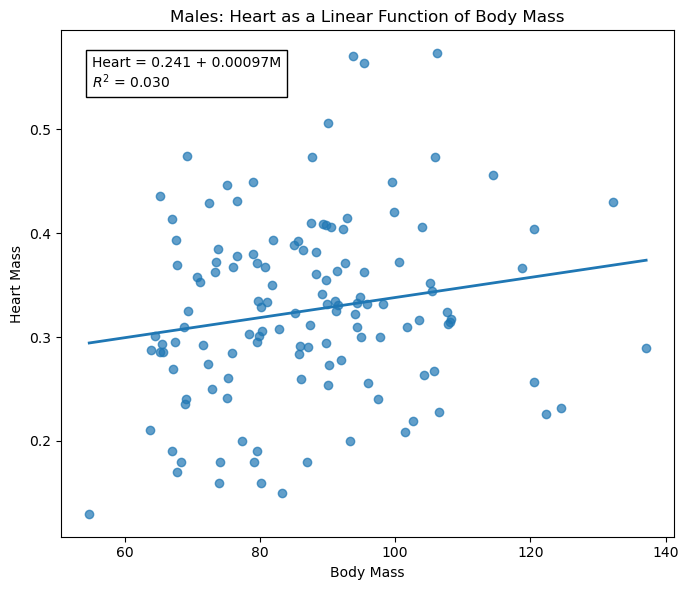

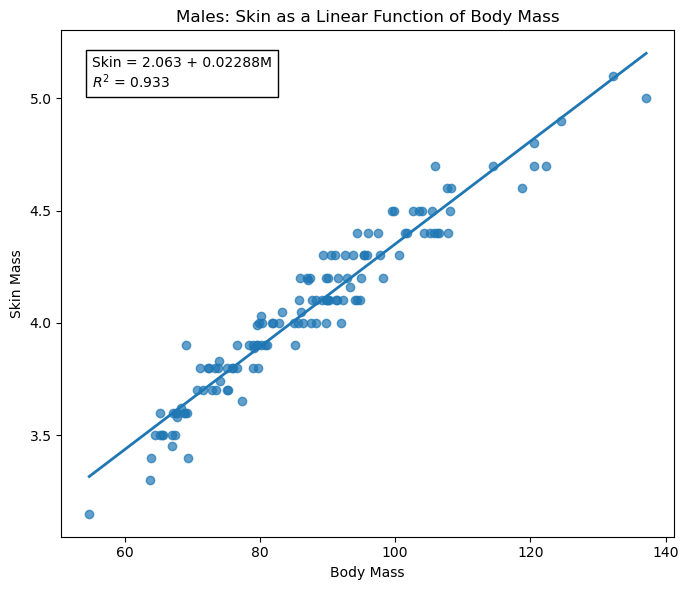

,organ,mean_weight
0,Skeletal Muscle,0.221016
1,Brain,0.209620
2,Liver,0.189400
3,Remaining Mass,0.104446
4,Kidneys,0.078232
5,Heart,0.077623
6,Adipose Tissue,0.057764
7,Bone,0.033838
8,Skin,0.026254
9,Spleen,0.001807


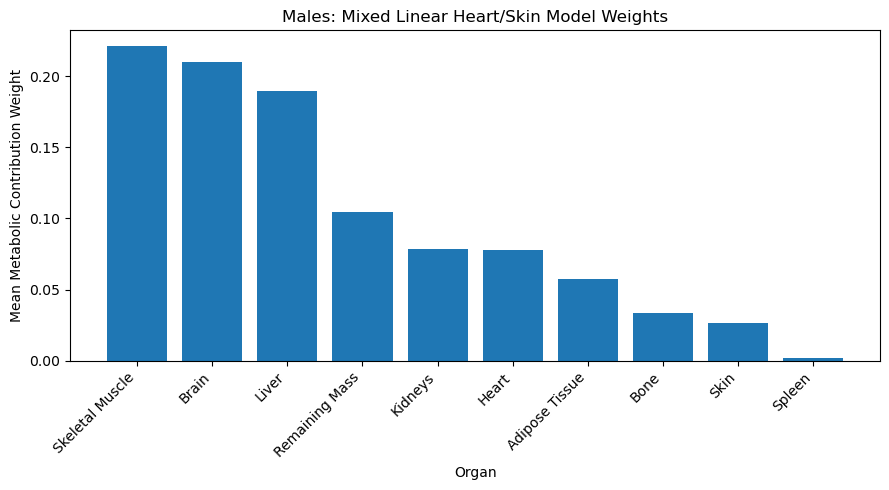

,Estimate,Beta
0,Direct REE power law,0.649822
1,All organ power laws,0.617464
2,Linear Heart + Skin,0.609475


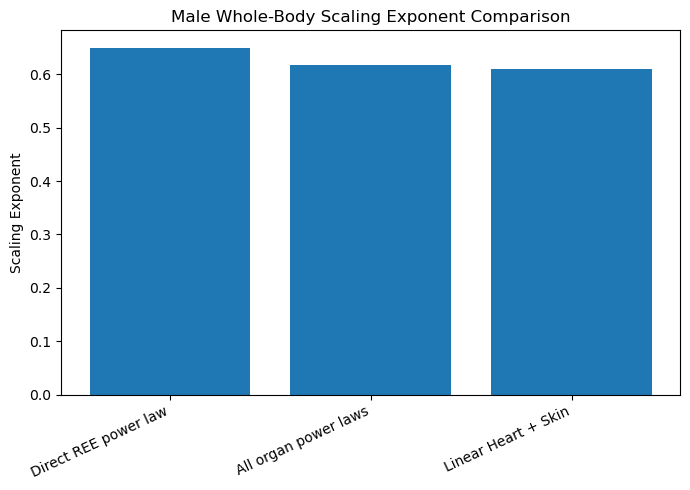

Beta comparison
Direct REE power law: 0.6498
All organ power laws: 0.6175
Linear Heart + Skin: 0.6095

At mean body weight:
Mean M = 87.05
Direct REE beta = 0.6498
Power-law organ beta = 0.6186
Linear Heart/Skin beta = 0.6111


In [24]:
# ======================================================
# Male sensitivity analysis
#
# Linear Heart
# Linear Skin
#
# All other organs remain power laws
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ------------------------------------------------------
# Build clean dataframe
# ------------------------------------------------------

linear_df = organ_df[[weight_col, ree_col] + organ_cols].copy()

for col in [weight_col, ree_col] + organ_cols:
    linear_df[col] = pd.to_numeric(
        linear_df[col],
        errors="coerce"
    )

linear_df = (
    linear_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

linear_df = linear_df[
    (linear_df[weight_col] > 0)
    & (linear_df[ree_col] > 0)
].copy()

# ------------------------------------------------------
# Fit linear Heart model
# ------------------------------------------------------

X_heart = sm.add_constant(
    linear_df[weight_col]
)

heart_model = sm.OLS(
    linear_df["Heart"],
    X_heart
).fit()

heart_a0 = heart_model.params["const"]
heart_a1 = heart_model.params[weight_col]

linear_df["Heart_pred_linear"] = (
    heart_a0
    + heart_a1 * linear_df[weight_col]
)

# ------------------------------------------------------
# Heart plot
# ------------------------------------------------------

plt.figure(figsize=(7,6))

plt.scatter(
    linear_df[weight_col],
    linear_df["Heart"],
    alpha=0.7
)

plot_temp = linear_df.sort_values(weight_col)

plt.plot(
    plot_temp[weight_col],
    plot_temp["Heart_pred_linear"],
    linewidth=2
)

plt.text(
    0.05,
    0.95,
    f"Heart = {heart_a0:.3f} + {heart_a1:.5f}M\n$R^2$ = {heart_model.rsquared:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white")
)

plt.xlabel("Body Mass")
plt.ylabel("Heart Mass")
plt.title("Males: Heart as a Linear Function of Body Mass")

plt.tight_layout()
plt.show()

# ------------------------------------------------------
# Fit linear Skin model
# ------------------------------------------------------

X_skin = sm.add_constant(
    linear_df[weight_col]
)

skin_model = sm.OLS(
    linear_df["Skin"],
    X_skin
).fit()

skin_a0 = skin_model.params["const"]
skin_a1 = skin_model.params[weight_col]

linear_df["Skin_pred_linear"] = (
    skin_a0
    + skin_a1 * linear_df[weight_col]
)

# ------------------------------------------------------
# Skin plot
# ------------------------------------------------------

plt.figure(figsize=(7,6))

plt.scatter(
    linear_df[weight_col],
    linear_df["Skin"],
    alpha=0.7
)

plot_temp = linear_df.sort_values(weight_col)

plt.plot(
    plot_temp[weight_col],
    plot_temp["Skin_pred_linear"],
    linewidth=2
)

plt.text(
    0.05,
    0.95,
    f"Skin = {skin_a0:.3f} + {skin_a1:.5f}M\n$R^2$ = {skin_model.rsquared:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white")
)

plt.xlabel("Body Mass")
plt.ylabel("Skin Mass")
plt.title("Males: Skin as a Linear Function of Body Mass")

plt.tight_layout()
plt.show()

# ------------------------------------------------------
# Compute mixed-model REE
# ------------------------------------------------------

linear_df["REE_pred_mixed"] = 0.0

numerator = 0.0
denominator = 0.0

for organ in organ_cols:

    K_i = elia_k[organ]

    if organ == "Heart":

        contribution = (
            K_i
            * (heart_a0 + heart_a1 * linear_df[weight_col])
        )

        beta_term = (
            K_i
            * heart_a1
            * linear_df[weight_col]
        )

    elif organ == "Skin":

        contribution = (
            K_i
            * (skin_a0 + skin_a1 * linear_df[weight_col])
        )

        beta_term = (
            K_i
            * skin_a1
            * linear_df[weight_col]
        )

    else:

        row = summary_table[
            summary_table["organ"] == organ
        ]

        alpha_i = row["alpha"].iloc[0]
        beta_i = row["beta"].iloc[0]

        contribution = (
            K_i
            * alpha_i
            * linear_df[weight_col] ** beta_i
        )

        beta_term = (
            beta_i
            * contribution
        )

    linear_df[f"{organ}_REE_mixed"] = contribution

    linear_df["REE_pred_mixed"] += contribution

    numerator += beta_term
    denominator += contribution

# ------------------------------------------------------
# Effective beta
# ------------------------------------------------------

linear_df["beta_eff_mixed"] = (
    numerator
    / denominator
)

# ------------------------------------------------------
# Mixed-model weights
# ------------------------------------------------------

mixed_weights = []

for organ in organ_cols:

    linear_df[f"{organ}_w_mixed"] = (
        linear_df[f"{organ}_REE_mixed"]
        / linear_df["REE_pred_mixed"]
    )

    mixed_weights.append({
        "organ": organ_name_map.get(organ, organ),
        "mean_weight":
            linear_df[f"{organ}_w_mixed"].mean()
    })

mean_mixed_weights = pd.DataFrame(
    mixed_weights
)

mean_mixed_weights = (
    mean_mixed_weights
    .sort_values(
        "mean_weight",
        ascending=False
    )
    .reset_index(drop=True)
)

display(mean_mixed_weights)

# ------------------------------------------------------
# Weight bar graph
# ------------------------------------------------------

plt.figure(figsize=(9,5))

plt.bar(
    mean_mixed_weights["organ"],
    mean_mixed_weights["mean_weight"]
)

plt.ylabel("Mean Metabolic Contribution Weight")
plt.xlabel("Organ")

plt.title(
    "Males: Mixed Linear Heart/Skin Model Weights"
)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# ------------------------------------------------------
# Beta comparison
# ------------------------------------------------------

# ------------------------------------------------------
# Beta comparison
# ------------------------------------------------------

# Compute all-power-law effective beta
# using the same organs but without the
# Heart/Skin linear substitutions

numerator_power = 0.0
denominator_power = 0.0

for organ in organ_cols:

    row = summary_table[
        summary_table["organ"] == organ
    ]

    alpha_i = row["alpha"].iloc[0]
    beta_i = row["beta"].iloc[0]
    K_i = elia_k[organ]

    contribution = (
        K_i
        * alpha_i
        * linear_df[weight_col] ** beta_i
    )

    numerator_power += (
        beta_i
        * contribution
    )

    denominator_power += contribution

linear_df["beta_eff_powerlaw_organs"] = (
    numerator_power
    / denominator_power
)

beta_comparison = pd.DataFrame({
    "Estimate": [
        "Direct REE power law",
        "All organ power laws",
        "Linear Heart + Skin"
    ],
    "Beta": [
        beta_REE_direct,
        linear_df["beta_eff_powerlaw_organs"].mean(),
        linear_df["beta_eff_mixed"].mean()
    ]
})

display(beta_comparison)

plt.figure(figsize=(7,5))

plt.bar(
    beta_comparison["Estimate"],
    beta_comparison["Beta"]
)

plt.ylabel("Scaling Exponent")

plt.title(
    "Male Whole-Body Scaling Exponent Comparison"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

print("Beta comparison")

for _, row in beta_comparison.iterrows():

    print(
        f"{row['Estimate']}: "
        f"{row['Beta']:.4f}"
    )

print("\nAt mean body weight:")

mean_M = linear_df[weight_col].mean()

sorted_df = linear_df.sort_values(
    weight_col
)

beta_power_at_mean = np.interp(
    mean_M,
    sorted_df[weight_col],
    sorted_df["beta_eff_powerlaw_organs"]
)

beta_mixed_at_mean = np.interp(
    mean_M,
    sorted_df[weight_col],
    sorted_df["beta_eff_mixed"]
)

print(f"Mean M = {mean_M:.2f}")
print(f"Direct REE beta = {beta_REE_direct:.4f}")
print(f"Power-law organ beta = {beta_power_at_mean:.4f}")
print(f"Linear Heart/Skin beta = {beta_mixed_at_mean:.4f}")

### 31. Bar plot of weights when AT is linear.

,Organ,Mean Weight
0,Skeletal Muscle,0.221016
1,Brain,0.209620
2,Liver,0.189400
3,Remaining Mass,0.104446
4,Kidneys,0.078232
5,Heart,0.077623
6,Adipose Tissue,0.057764
7,Bone,0.033838
8,Skin,0.026254
9,Spleen,0.001807


Sum of mean mixed-model weights:
1.0000000000000002


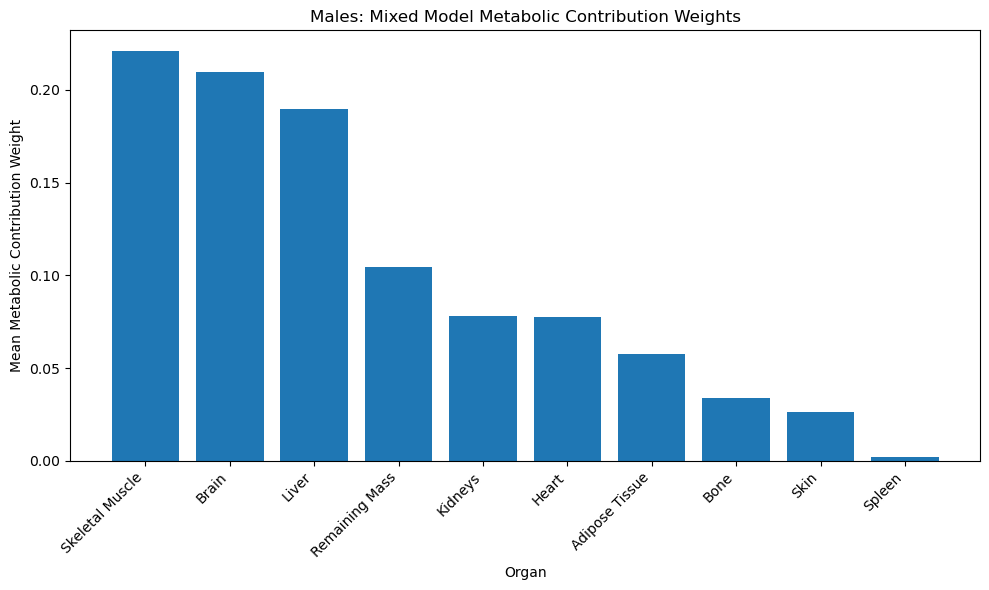

In [25]:
# ======================================================
# Male mixed-model metabolic contribution weights
# Linear Heart and Skin; all other organs power laws
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Build clean dataframe
# ------------------------------------------------------

mixed_weight_df = organ_df[[weight_col] + organ_cols].copy()

for col in [weight_col] + organ_cols:
    mixed_weight_df[col] = pd.to_numeric(
        mixed_weight_df[col],
        errors="coerce"
    )

mixed_weight_df = mixed_weight_df.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

mixed_weight_df = mixed_weight_df[
    mixed_weight_df[weight_col] > 0
].copy()

# ------------------------------------------------------
# Total mixed-model REE denominator
# ------------------------------------------------------

mixed_weight_df["REE_total_mixed"] = 0.0

for organ in organ_cols:

    K_i = elia_k[organ]

    if organ == "Heart":

        term = (
            K_i
            * (heart_a0 + heart_a1 * mixed_weight_df[weight_col])
        )

    elif organ == "Skin":

        term = (
            K_i
            * (skin_a0 + skin_a1 * mixed_weight_df[weight_col])
        )

    else:

        row = summary_table[
            summary_table["organ"] == organ
        ]

        if row.empty:
            raise ValueError(f"{organ} not found in summary_table.")

        alpha_i = row["alpha"].iloc[0]
        beta_i = row["beta"].iloc[0]

        term = (
            K_i
            * alpha_i
            * mixed_weight_df[weight_col] ** beta_i
        )

    mixed_weight_df[f"{organ}_REE_term_mixed"] = term
    mixed_weight_df["REE_total_mixed"] += term

# ------------------------------------------------------
# Compute mixed-model weights
# ------------------------------------------------------

for organ in organ_cols:
    mixed_weight_df[f"{organ}_weight_mixed"] = (
        mixed_weight_df[f"{organ}_REE_term_mixed"]
        / mixed_weight_df["REE_total_mixed"]
    )

# ------------------------------------------------------
# Summary table
# ------------------------------------------------------

weights_summary = pd.DataFrame({
    "Organ": [
        organ_name_map.get(organ, organ)
        for organ in organ_cols
    ],
    "Mean Weight": [
        mixed_weight_df[f"{organ}_weight_mixed"].mean()
        for organ in organ_cols
    ]
})

weights_summary = weights_summary.sort_values(
    "Mean Weight",
    ascending=False
).reset_index(drop=True)

display(weights_summary)

print("Sum of mean mixed-model weights:")
print(weights_summary["Mean Weight"].sum())

# ------------------------------------------------------
# Plot
# ------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    weights_summary["Organ"],
    weights_summary["Mean Weight"]
)

plt.ylabel("Mean Metabolic Contribution Weight")
plt.xlabel("Organ")
plt.title("Males: Mixed Model Metabolic Contribution Weights")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Demographics

In [26]:
# ======================================================
# Participant characteristics table
# Complete-case reference dataset used in analysis
# Values reported as mean (SD)
# ======================================================

def mean_sd(series):
    series = pd.to_numeric(series, errors="coerce").dropna()
    return f"{series.mean():.2f} ({series.std(ddof=1):.2f})"

# ------------------------------------------------------
# Find demographic columns robustly
# ------------------------------------------------------

col_lookup = {
    col.lower().strip(): col
    for col in df.columns
}

age_col = col_lookup.get("age")
height_col = col_lookup.get("height")

print("Age column:", age_col)
print("Height column:", height_col)

# ------------------------------------------------------
# Build complete-case reference dataset
# Uses the same required variables as the main analysis
# ------------------------------------------------------

reference_cols = [weight_col, ree_col] + organ_cols

if age_col is not None:
    reference_cols.append(age_col)

if height_col is not None:
    reference_cols.append(height_col)

reference_df = df[reference_cols].copy()

for col in reference_cols:
    reference_df[col] = pd.to_numeric(reference_df[col], errors="coerce")

reference_df = (
    reference_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

reference_df = reference_df[
    (reference_df[weight_col] > 0)
    & (reference_df[ree_col] > 0)
].copy()

for organ in organ_cols:
    reference_df = reference_df[
        reference_df[organ] > 0
    ].copy()

# ------------------------------------------------------
# Derived variables
# Height is in meters in these files
# ------------------------------------------------------

if height_col is not None:
    reference_df["BMI"] = (
        reference_df[weight_col]
        / reference_df[height_col] ** 2
    )

reference_df["Total organ mass"] = reference_df[organ_cols].sum(axis=1)

# ------------------------------------------------------
# Characteristics table
# ------------------------------------------------------

sex_label = "Males"  # change to "Males" in male notebook

rows = [
    ("n", str(len(reference_df))),
    ("Age, years", mean_sd(reference_df[age_col]) if age_col is not None else "Column not found"),
    ("Height, m", mean_sd(reference_df[height_col]) if height_col is not None else "Column not found"),
    ("Body mass, kg", mean_sd(reference_df[weight_col])),
    ("BMI, kg/m²", mean_sd(reference_df["BMI"]) if "BMI" in reference_df.columns else "Column not found"),
    ("Measured RMR, kcal/day", mean_sd(reference_df[ree_col])),
    ("Adipose tissue mass, kg", mean_sd(reference_df["AT"])),
    ("Skeletal muscle mass, kg", mean_sd(reference_df["SM"])),
    ("Total modeled tissue mass, kg", mean_sd(reference_df["Total organ mass"]))
]

reference_characteristics_table = pd.DataFrame(
    rows,
    columns=["Characteristic", sex_label]
)

display(reference_characteristics_table)

Age column: Age
Height column: Height


,Characteristic,Males
0,n,131
1,"Age, years",45.33 (15.41)
2,"Height, m",1.79 (0.06)
3,"Body mass, kg",87.05 (15.61)
4,"BMI, kg/m²",27.25 (4.42)
5,"Measured RMR, kcal/day",1810.44 (251.37)
6,"Adipose tissue mass, kg",24.99 (9.84)
7,"Skeletal muscle mass, kg",31.85 (5.51)
8,"Total modeled tissue mass, kg",87.06 (15.62)


,Sex,Ki set,Mean effective beta,SD effective beta,Mean predicted REE,Change in beta vs Elia,Percent change in beta vs Elia
0,Male,Elia,0.617464,0.032211,1852.489827,0.000000,0.000000
1,Male,Wang sex-specific midpoint,0.616919,0.031873,1795.973446,-0.000546,-0.088405


,organ,mean_REE_weight_Elia,mean_REE_weight_Wang,difference_Wang_minus_Elia
0,Skeletal Muscle,0.222258,0.223962,0.001704
1,Brain,0.208297,0.209928,0.001631
2,Liver,0.190754,0.192822,0.002068
3,Remaining Mass,0.104785,0.105380,0.000595
4,Kidneys,0.078118,0.074075,-0.004043
5,Heart,0.074575,0.071939,-0.002636
6,Adipose Tissue,0.059439,0.058176,-0.001263
7,Bone,0.033693,0.034753,0.001060
8,Skin,0.026260,0.027087,0.000826
9,Spleen,0.001821,0.001879,0.000057


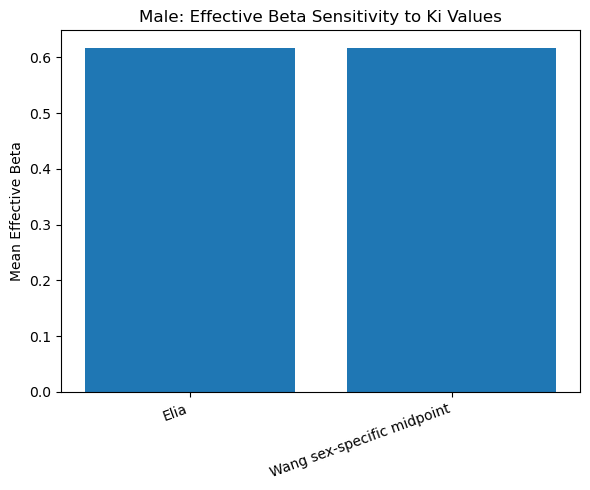


Bottom line:
Male: Wang midpoint Ki values changed mean effective beta by -0.000546 (-0.09%).


In [31]:
# ======================================================
# Sensitivity analysis:
# Effective beta using Wang-adjusted sex-specific Ki values
#
# Compares Elia Ki values with sex-specific midpoint values
# from Wang et al. confidence intervals reported in Muller et al. 2013.
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Identify sex from column naming
# ------------------------------------------------------

is_female = "heart" in organ_cols
sex_label = "Female" if is_female else "Male"

# ------------------------------------------------------
# Elia Ki values, kcal/kg/day
# NOTE:
# Bone, skin, spleen are retained as 12 because the Wang/Elia
# 7-compartment summaries treat these within residual/remaining mass.
# ------------------------------------------------------

elia_k_sensitivity = {
    "AT": 4.5,
    "SM": 13,
    "Bone": 12,
    "Liver": 200,
    "Kidney": 440,
    "Spleen": 12,
    "Brain": 240,
    "Skin": 12,
    "Residual": 12
}

if is_female:
    elia_k_sensitivity["heart"] = 440
else:
    elia_k_sensitivity["Heart"] = 440

# ------------------------------------------------------
# Wang sex-specific midpoint Ki values from reported 95% CIs
#
# Male CIs:
# AT 2.83-5.71, SM 11.9-13.5, Liver 179-213,
# Brain 216-253, Heart 342-481, Kidney 325-484,
# Residual 10.8-12.6
#
# Female CIs:
# AT 3.82-5.14, SM 12.0-13.8, Liver 183-214,
# Brain 223-254, Heart 342-488, Kidney 339-491,
# Residual 10.9-12.8
# ------------------------------------------------------

if is_female:

    wang_k_sensitivity = {
        "AT": (3.82 + 5.14) / 2,
        "SM": (12.0 + 13.8) / 2,
        "Bone": 12,
        "Liver": (183 + 214) / 2,
        "heart": (342 + 488) / 2,
        "Kidney": (339 + 491) / 2,
        "Spleen": 12,
        "Brain": (223 + 254) / 2,
        "Skin": 12,
        "Residual": (10.9 + 12.8) / 2
    }

else:

    wang_k_sensitivity = {
        "AT": (2.83 + 5.71) / 2,
        "SM": (11.9 + 13.5) / 2,
        "Bone": 12,
        "Liver": (179 + 213) / 2,
        "Heart": (342 + 481) / 2,
        "Kidney": (325 + 484) / 2,
        "Spleen": 12,
        "Brain": (216 + 253) / 2,
        "Skin": 12,
        "Residual": (10.8 + 12.6) / 2
    }

# ------------------------------------------------------
# Helper function: compute effective beta
# beta_eff(M) = sum_i Ki alpha_i beta_i M^beta_i /
#               sum_i Ki alpha_i M^beta_i
# ------------------------------------------------------

def compute_effective_beta_from_k(k_dict, label):

    beta_df = organ_df[[weight_col] + organ_cols].copy()

    for col in [weight_col] + organ_cols:
        beta_df[col] = pd.to_numeric(beta_df[col], errors="coerce")

    beta_df = beta_df.replace([np.inf, -np.inf], np.nan).dropna()
    beta_df = beta_df[beta_df[weight_col] > 0].copy()

    numerator = 0.0
    denominator = 0.0

    component_rows = []

    for organ in organ_cols:

        row = summary_table[summary_table["organ"] == organ]

        if row.empty:
            raise ValueError(f"{organ} not found in summary_table.")

        alpha_i = row["alpha"].iloc[0]
        beta_i = row["beta"].iloc[0]
        K_i = k_dict[organ]

        contribution = (
            K_i
            * alpha_i
            * beta_df[weight_col] ** beta_i
        )

        numerator += beta_i * contribution
        denominator += contribution

        beta_df[f"{organ}_{label}_REE_contribution"] = contribution

        component_rows.append({
            "organ": organ_name_map.get(organ, organ),
            "K": K_i,
            "beta_i": beta_i,
            "mean_REE_weight": contribution.mean()
        })

    beta_df[f"beta_eff_{label}"] = numerator / denominator
    beta_df[f"REE_pred_{label}"] = denominator

    component_table = pd.DataFrame(component_rows)
    component_table["mean_REE_weight"] = (
        component_table["mean_REE_weight"]
        / component_table["mean_REE_weight"].sum()
    )

    component_table = component_table.sort_values(
        "mean_REE_weight",
        ascending=False
    ).reset_index(drop=True)

    return beta_df, component_table

# ------------------------------------------------------
# Run Elia vs Wang sensitivity analysis
# ------------------------------------------------------

elia_beta_df, elia_component_table = compute_effective_beta_from_k(
    elia_k_sensitivity,
    "Elia"
)

wang_beta_df, wang_component_table = compute_effective_beta_from_k(
    wang_k_sensitivity,
    "Wang"
)

# ------------------------------------------------------
# Summarize effective beta
# ------------------------------------------------------

beta_sensitivity = pd.DataFrame({
    "Sex": [sex_label, sex_label],
    "Ki set": ["Elia", "Wang sex-specific midpoint"],
    "Mean effective beta": [
        elia_beta_df["beta_eff_Elia"].mean(),
        wang_beta_df["beta_eff_Wang"].mean()
    ],
    "SD effective beta": [
        elia_beta_df["beta_eff_Elia"].std(ddof=1),
        wang_beta_df["beta_eff_Wang"].std(ddof=1)
    ],
    "Mean predicted REE": [
        elia_beta_df["REE_pred_Elia"].mean(),
        wang_beta_df["REE_pred_Wang"].mean()
    ]
})

beta_sensitivity["Change in beta vs Elia"] = (
    beta_sensitivity["Mean effective beta"]
    - beta_sensitivity.loc[
        beta_sensitivity["Ki set"] == "Elia",
        "Mean effective beta"
    ].iloc[0]
)

beta_sensitivity["Percent change in beta vs Elia"] = (
    100
    * beta_sensitivity["Change in beta vs Elia"]
    / beta_sensitivity.loc[
        beta_sensitivity["Ki set"] == "Elia",
        "Mean effective beta"
    ].iloc[0]
)

display(beta_sensitivity)

# ------------------------------------------------------
# Compare organ weights
# ------------------------------------------------------

weight_compare = elia_component_table[["organ", "mean_REE_weight"]].merge(
    wang_component_table[["organ", "mean_REE_weight"]],
    on="organ",
    suffixes=("_Elia", "_Wang")
)

weight_compare["difference_Wang_minus_Elia"] = (
    weight_compare["mean_REE_weight_Wang"]
    - weight_compare["mean_REE_weight_Elia"]
)

weight_compare = weight_compare.sort_values(
    "mean_REE_weight_Elia",
    ascending=False
).reset_index(drop=True)

display(weight_compare)

# ------------------------------------------------------
# Save output tables
# ------------------------------------------------------

beta_sensitivity.to_csv(
    f"{sex_label}_Ki_sensitivity_effective_beta.csv",
    index=False
)

weight_compare.to_csv(
    f"{sex_label}_Ki_sensitivity_organ_weights.csv",
    index=False
)

# ------------------------------------------------------
# Plot beta comparison
# ------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.bar(
    beta_sensitivity["Ki set"],
    beta_sensitivity["Mean effective beta"]
)

plt.ylabel("Mean Effective Beta")
plt.title(f"{sex_label}: Effective Beta Sensitivity to Ki Values")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    f"{sex_label}_Ki_sensitivity_effective_beta.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nBottom line:")
print(
    f"{sex_label}: Wang midpoint Ki values changed mean effective beta by "
    f"{beta_sensitivity.loc[1, 'Change in beta vs Elia']:.6f} "
    f"({beta_sensitivity.loc[1, 'Percent change in beta vs Elia']:.2f}%)."
)